=============================================================================
DATA-DRIVEN SURROGATE MODELLING AND MULTI-OBJECTIVE OPTIMIZATION
OF WEDM PROCESS PARAMETERS FOR Ti-6Al-4V ALLOY
=============================================================================
Pipeline: L9 Experimental Data → RSM Expansion (~1100 pts) → ML Surrogates
          (RF, SVR, XGBoost, ANN) → NSGA-II Optimization → TOPSIS Decision
=============================================================================

In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("pymoo==0.6.1.3")
install("xgboost")
install("shap")

print("All dependencies installed.")


All dependencies installed.


In [ ]:
# =============================================================================
# SECTION 2: IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
from itertools import product

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.indicators.hv import Hypervolume

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

SAVE_DIR = "./wedm_results"
os.makedirs(SAVE_DIR, exist_ok=True)

print("All imports loaded successfully.")

All imports loaded successfully.


L9 Experimental Data with RSM Predictions:
 Ip  Ton  Toff  Vs  MRR   SR  RSM_MRR  RSM_SR
 20  110    50 220 7.87 2.14 7.896200    2.14
 20  115    55 230 7.98 2.19 8.006150    2.19
 20  120    60 240 8.08 2.23 8.106000    2.23
 25  110    55 240 8.22 2.47 8.243550    2.47
 25  115    60 220 8.35 2.66 8.377050    2.66
 25  120    50 230 8.56 2.84 8.587525    2.84
 30  110    60 230 8.47 2.56 8.494500    2.56
 30  115    50 240 8.78 3.01 8.804925    3.01
 30  120    55 220 8.29 2.79 8.318425    2.79

RSM fit on L9 — MRR R²: 0.990873
RSM fit on L9 — SR  R²: 1.000000
Full integer grid size: 27,951 points

Expanded dataset: 1100 points
  - Original 81 full-factorial points included: 81
  - Additional sampled points: 1019

Dataset statistics:
              Ip        Ton       Toff         Vs        MRR         SR
count  1100.0000  1100.0000  1100.0000  1100.0000  1100.0000  1100.0000
mean     25.0900   115.0009    55.0236   230.0136     8.3579     2.5951
std       3.1409     3.2400     3.229

  Fold 2: MRR R²=0.5879, SR R²=0.5388
  Fold 3: MRR R²=0.5554, SR R²=0.6490
  Fold 4: MRR R²=0.5546, SR R²=0.5816
  Fold 5: MRR R²=0.5991, SR R²=0.5129

ANN — 5-Fold CV Results:
  MRR  R² = 0.6585 ± 0.1694  RMSE = 0.1114 ± 0.0489
  SR   R² = 0.5999 ± 0.0745  RMSE = 0.1414 ± 0.0137
ANN models saved.

EXTERNAL VALIDATION ON L9 EXPERIMENTAL DATA (9 points)
         Model  MRR_R2  MRR_RMSE  MRR_MAE  SR_R2  SR_RMSE  SR_MAE
            RF  0.9860    0.0323   0.0282 0.9990   0.0092  0.0074
           SVR  0.9910    0.0260   0.0258 1.0000   0.0020  0.0019
       XGBoost  0.9886    0.0291   0.0277 0.9995   0.0063  0.0046
           ANN  0.5798    0.1769   0.1653 0.4794   0.2113  0.1735
RSM (Baseline)  0.9909    0.0261   0.0260 1.0000   0.0000  0.0000

5-FOLD CROSS-VALIDATION COMPARISON
        Model  MRR_R2_mean  MRR_R2_std  MRR_RMSE_mean  MRR_RMSE_std  SR_R2_mean  SR_R2_std  SR_RMSE_mean  SR_RMSE_std
Random Forest       0.9737      0.0032         0.0337        0.0025      0.9924     0.0017    

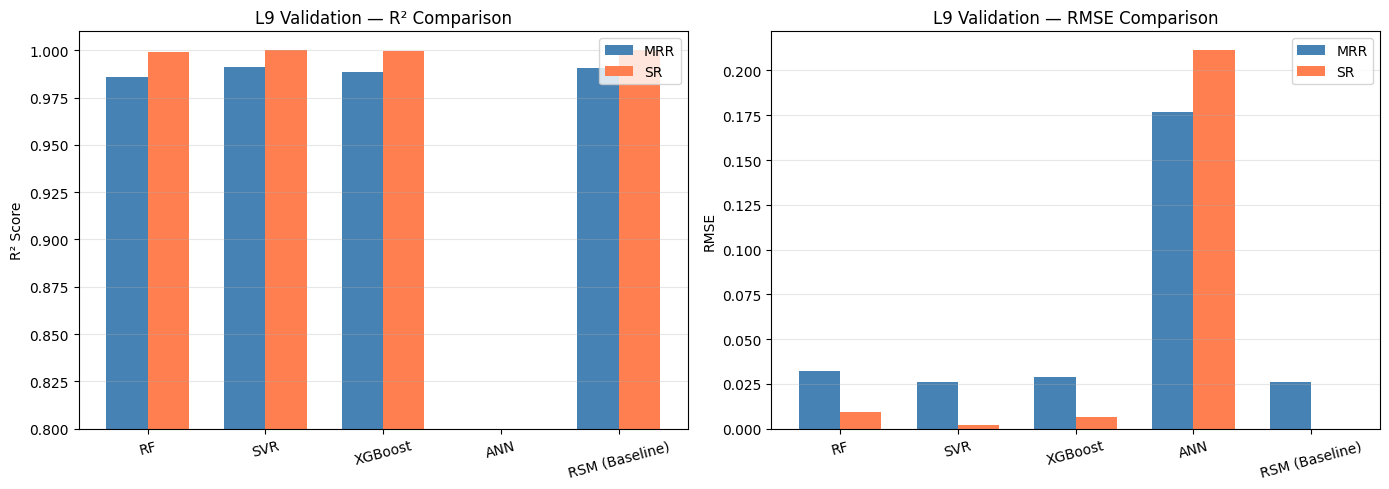

Model comparison plot saved.


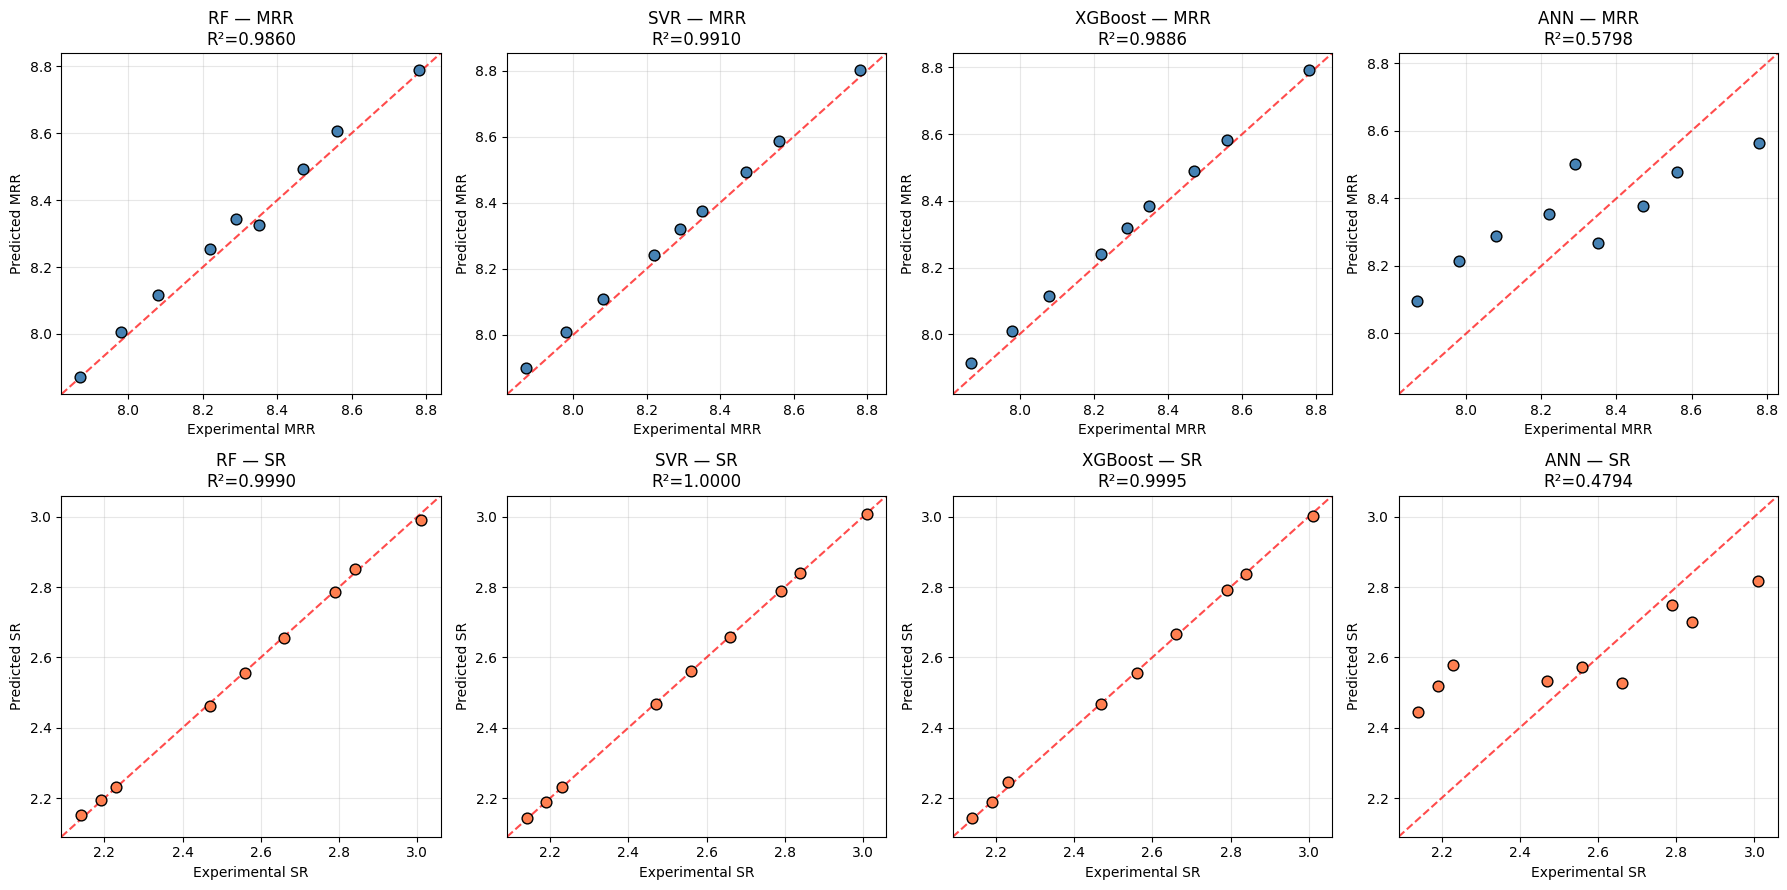

Predicted vs Actual plots saved.

NSGA-II MULTI-OBJECTIVE OPTIMIZATION

Running NSGA-II with RF surrogate...
  RF: 155 unique Pareto solutions
  MRR range: [7.7711, 8.7924]
  SR  range: [1.9602, 2.9824]

Running NSGA-II with SVR surrogate...
  SVR: 167 unique Pareto solutions
  MRR range: [7.7416, 8.8205]
  SR  range: [1.9372, 3.0125]

Running NSGA-II with XGBoost surrogate...
  XGBoost: 160 unique Pareto solutions
  MRR range: [7.7645, 8.7987]
  SR  range: [1.9592, 2.9839]

Running NSGA-II with ANN surrogate...
  ANN: 133 unique Pareto solutions
  MRR range: [8.1191, 8.6315]
  SR  range: [2.3795, 2.8533]


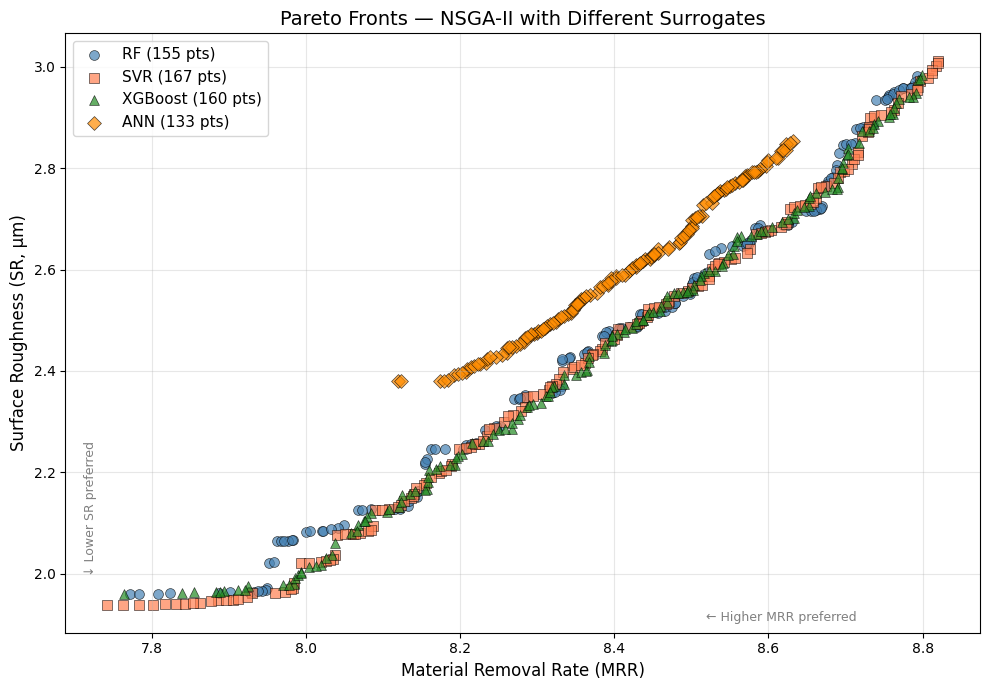

Pareto front comparison plot saved.

PARETO FRONT QUALITY METRICS
Surrogate  Hypervolume  N_solutions      MRR_range       SR_range
       RF     0.911463          155 [7.771, 8.792] [1.960, 2.982]
      SVR     0.936563          167 [7.742, 8.820] [1.937, 3.013]
  XGBoost     0.927659          160 [7.764, 8.799] [1.959, 2.984]
      ANN     0.627288          133 [8.119, 8.631] [2.379, 2.853]

TOPSIS & KNEE-POINT DECISION ANALYSIS

--- RF Surrogate ---
  TOPSIS Equal (0.5, 0.5): Ip=20, Ton=110, Toff=60, Vs=233 → MRR=7.9479, SR=1.9681 (score=0.8019)
  TOPSIS MRR-priority (0.7, 0.3): Ip=20, Ton=113, Toff=60, Vs=235 → MRR=8.1327, SR=2.1327 (score=0.6445)
  TOPSIS SR-priority (0.3, 0.7): Ip=20, Ton=110, Toff=60, Vs=233 → MRR=7.9479, SR=1.9681 (score=0.9040)
  Knee Point: Ip=20, Ton=113, Toff=60, Vs=235 → MRR=8.1327, SR=2.1327

--- SVR Surrogate ---
  TOPSIS Equal (0.5, 0.5): Ip=20, Ton=110, Toff=60, Vs=234 → MRR=7.9802, SR=1.9689 (score=0.8082)
  TOPSIS MRR-priority (0.7, 0.3): Ip=20, Ton=

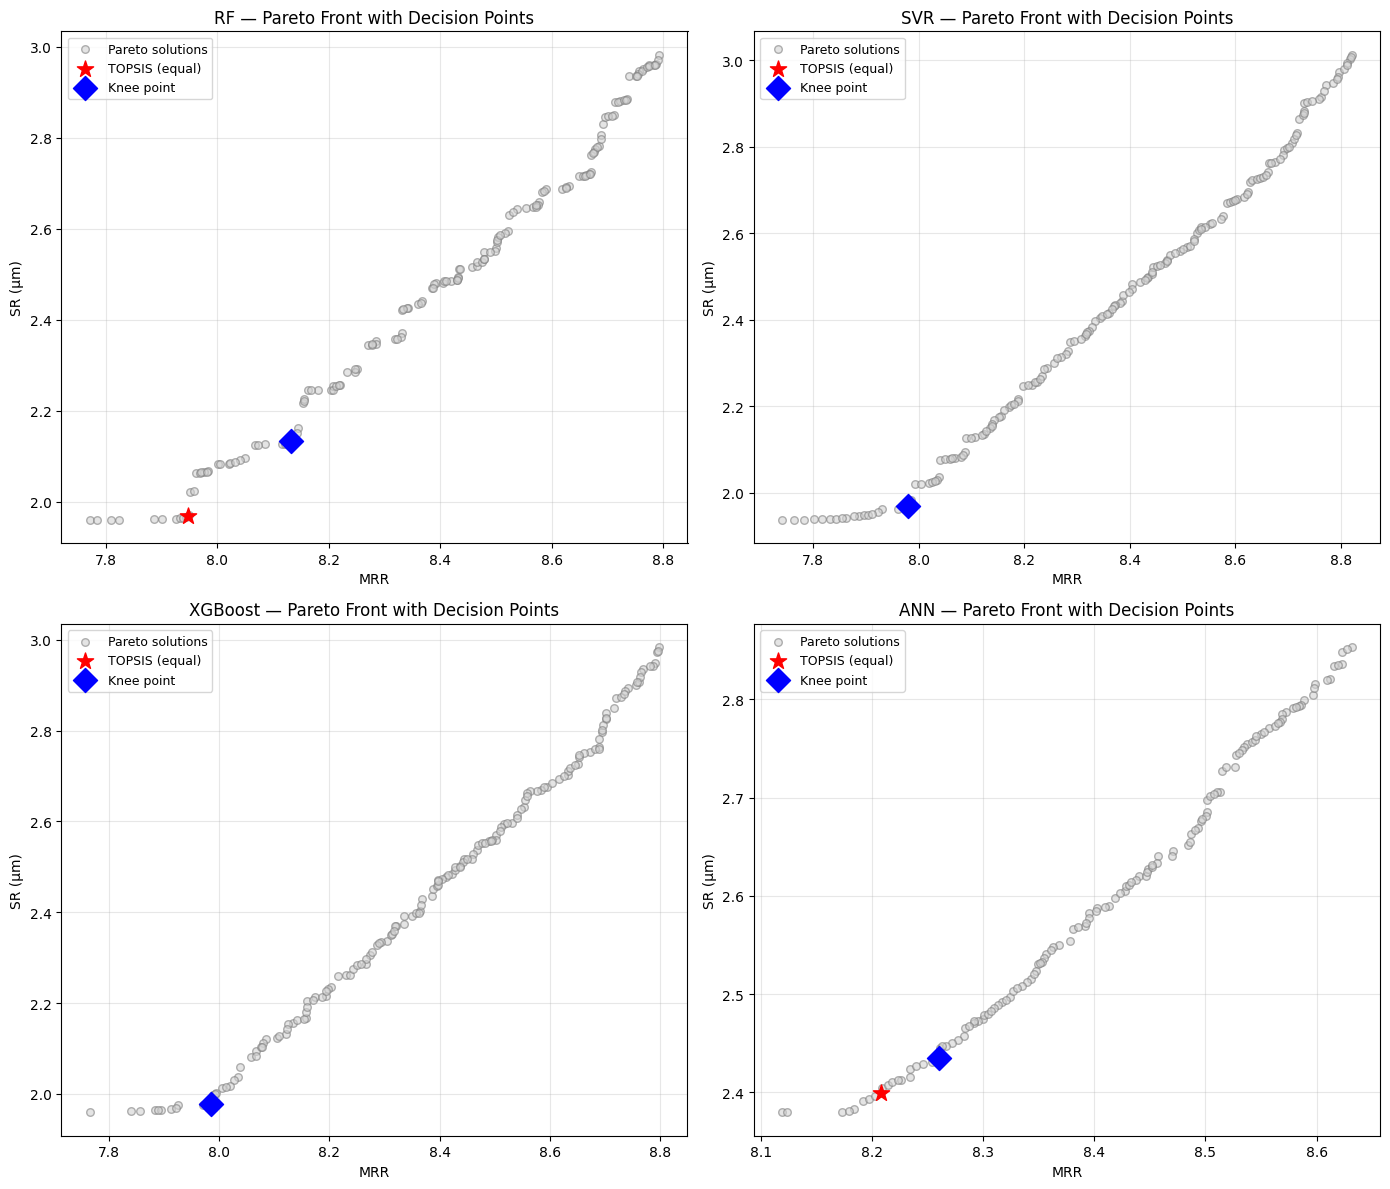

Decision analysis plots saved.

FINAL SUMMARY

1. DATASET: RSM-expanded from L9 (9 pts) to 1,100 integer points
   Parameter ranges: Ip=[20,30], Ton=[110,120], Toff=[50,60], Vs=[220,240]

2. CROSS-VALIDATION RESULTS (5-Fold on expanded dataset):
        Model  MRR_R2_mean  MRR_RMSE_mean  SR_R2_mean  SR_RMSE_mean
Random Forest       0.9737         0.0337      0.9924        0.0194
          SVR       0.9997         0.0033      0.9997        0.0038
      XGBoost       0.9917         0.0189      0.9942        0.0171
          ANN       0.6585         0.1114      0.5999        0.1414

3. EXTERNAL VALIDATION (L9 experimental data):
         Model  MRR_R2  MRR_RMSE  SR_R2  SR_RMSE
            RF  0.9860    0.0323 0.9990   0.0092
           SVR  0.9910    0.0260 1.0000   0.0020
       XGBoost  0.9886    0.0291 0.9995   0.0063
           ANN  0.5798    0.1769 0.4794   0.2113
RSM (Baseline)  0.9909    0.0261 1.0000   0.0000

4. HYPERVOLUME (larger = better Pareto front):
Surrogate  Hypervolume  

In [ ]:
# =============================================================================
# SECTION 3: DEFINE RSM EQUATIONS AND EXPERIMENTAL DATA
# =============================================================================

# --- RSM Equations from Minitab (uncoded units) ---
def rsm_mrr(Ip, Ton, Toff, Vs):
    """MRR = f(Ip, Ton, Toff, Vs) — quadratic RSM from Minitab"""
    return (-78.77
            + 0.3170 * Ip + 1.132 * Ton - 0.8390 * Toff + 0.3392 * Vs
            - 0.005267 * Ip**2 - 0.004867 * Ton**2
            + 0.007533 * Toff**2 - 0.000717 * Vs**2)

def rsm_sr(Ip, Ton, Toff, Vs):
    """SR = f(Ip, Ton, Toff, Vs) — quadratic RSM from Minitab"""
    return (-44.57
            + 0.4000 * Ip + 1.081 * Ton - 0.4140 * Toff - 0.09000 * Vs
            - 0.006800 * Ip**2 - 0.004600 * Ton**2
            + 0.003600 * Toff**2 + 0.000200 * Vs**2)

# --- Original L9 Experimental Data (ground truth for validation) ---
l9_data = pd.DataFrame({
    'Ip':   [20, 20, 20, 25, 25, 25, 30, 30, 30],
    'Ton':  [110, 115, 120, 110, 115, 120, 110, 115, 120],
    'Toff': [50, 55, 60, 55, 60, 50, 60, 50, 55],
    'Vs':   [220, 230, 240, 240, 220, 230, 230, 240, 220],
    'MRR':  [7.87, 7.98, 8.08, 8.22, 8.35, 8.56, 8.47, 8.78, 8.29],
    'SR':   [2.14, 2.19, 2.23, 2.47, 2.66, 2.84, 2.56, 3.01, 2.79]
})

# Verify RSM fits L9 data
l9_data['RSM_MRR'] = rsm_mrr(l9_data.Ip, l9_data.Ton, l9_data.Toff, l9_data.Vs)
l9_data['RSM_SR'] = rsm_sr(l9_data.Ip, l9_data.Ton, l9_data.Toff, l9_data.Vs)

print("L9 Experimental Data with RSM Predictions:")
print(l9_data.to_string(index=False))
print(f"\nRSM fit on L9 — MRR R²: {r2_score(l9_data.MRR, l9_data.RSM_MRR):.6f}")
print(f"RSM fit on L9 — SR  R²: {r2_score(l9_data.SR, l9_data.RSM_SR):.6f}")

# =============================================================================
# SECTION 4: GENERATE EXPANDED DATASET (~1100 POINTS)
# =============================================================================

# Full integer grid
ip_range   = np.arange(20, 31, 1)    # 11 values
ton_range  = np.arange(110, 121, 1)   # 11 values
toff_range = np.arange(50, 61, 1)     # 11 values
vs_range   = np.arange(220, 241, 1)   # 21 values

full_grid = np.array(list(product(ip_range, ton_range, toff_range, vs_range)))
print(f"Full integer grid size: {len(full_grid):,} points")

# Compute RSM predictions for entire grid
full_mrr = rsm_mrr(full_grid[:,0], full_grid[:,1], full_grid[:,2], full_grid[:,3])
full_sr  = rsm_sr(full_grid[:,0], full_grid[:,1], full_grid[:,2], full_grid[:,3])

# Identify the original 81 full-factorial points (3 levels each)
original_levels = {
    'Ip': [20, 25, 30], 'Ton': [110, 115, 120],
    'Toff': [50, 55, 60], 'Vs': [220, 230, 240]
}
orig_81 = np.array(list(product(
    original_levels['Ip'], original_levels['Ton'],
    original_levels['Toff'], original_levels['Vs']
)))

# Find indices of the 81 points in the full grid
orig_81_set = set(map(tuple, orig_81))
orig_indices = [i for i, row in enumerate(full_grid) if tuple(row) in orig_81_set]
remaining_indices = [i for i in range(len(full_grid)) if i not in orig_indices]

# Sample additional points to reach ~1100 total
n_additional = 1100 - len(orig_indices)
np.random.seed(42)
sampled_indices = np.random.choice(remaining_indices, size=n_additional, replace=False)

# Combine: 81 original + ~1019 sampled
selected_indices = np.array(orig_indices + list(sampled_indices))
expanded_X = full_grid[selected_indices]
expanded_mrr = full_mrr[selected_indices]
expanded_sr = full_sr[selected_indices]

# Create DataFrame
expanded_df = pd.DataFrame(expanded_X, columns=['Ip', 'Ton', 'Toff', 'Vs'])
expanded_df['MRR'] = expanded_mrr
expanded_df['SR'] = expanded_sr

# Save expanded dataset
expanded_df.to_csv(f"{SAVE_DIR}/expanded_dataset_1100.csv", index=False)

print(f"\nExpanded dataset: {len(expanded_df)} points")
print(f"  - Original 81 full-factorial points included: {len(orig_indices)}")
print(f"  - Additional sampled points: {n_additional}")
print(f"\nDataset statistics:")
print(expanded_df.describe().round(4).to_string())

# =============================================================================
# SECTION 5: DATA PREPARATION AND SCALING
# =============================================================================

feature_cols = ['Ip', 'Ton', 'Toff', 'Vs']

X_train_full = expanded_df[feature_cols].values
y_mrr_train = expanded_df['MRR'].values
y_sr_train = expanded_df['SR'].values

X_val = l9_data[feature_cols].values
y_mrr_val = l9_data['MRR'].values
y_sr_val = l9_data['SR'].values

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_full)
X_val_scaled = scaler_X.transform(X_val)

# Scale targets (needed for SVR and ANN)
scaler_mrr = StandardScaler()
scaler_sr = StandardScaler()
y_mrr_scaled = scaler_mrr.fit_transform(y_mrr_train.reshape(-1, 1)).ravel()
y_sr_scaled = scaler_sr.fit_transform(y_sr_train.reshape(-1, 1)).ravel()

# Save scalers
joblib.dump(scaler_X, f"{SAVE_DIR}/scaler_X.joblib")
joblib.dump(scaler_mrr, f"{SAVE_DIR}/scaler_mrr.joblib")
joblib.dump(scaler_sr, f"{SAVE_DIR}/scaler_sr.joblib")

print("Scalers fitted and saved.")
print(f"Training set: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Validation set (L9): {X_val_scaled.shape[0]} samples")

# =============================================================================
# SECTION 6: 5-FOLD CROSS-VALIDATION SETUP
# =============================================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(model_class, params, X, y_mrr, y_sr, model_name):
    """Run 5-fold CV and return metrics for both MRR and SR."""
    mrr_r2, mrr_rmse, sr_r2, sr_rmse = [], [], [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_mrr_tr, y_mrr_te = y_mrr[train_idx], y_mrr[test_idx]
        y_sr_tr, y_sr_te = y_sr[train_idx], y_sr[test_idx]

        # MRR model
        m_mrr = model_class(**params)
        m_mrr.fit(X_tr, y_mrr_tr)
        pred_mrr = m_mrr.predict(X_te)
        mrr_r2.append(r2_score(y_mrr_te, pred_mrr))
        mrr_rmse.append(np.sqrt(mean_squared_error(y_mrr_te, pred_mrr)))

        # SR model
        m_sr = model_class(**params)
        m_sr.fit(X_tr, y_sr_tr)
        pred_sr = m_sr.predict(X_te)
        sr_r2.append(r2_score(y_sr_te, pred_sr))
        sr_rmse.append(np.sqrt(mean_squared_error(y_sr_te, pred_sr)))

    results = {
        'Model': model_name,
        'MRR_R2_mean': np.mean(mrr_r2), 'MRR_R2_std': np.std(mrr_r2),
        'MRR_RMSE_mean': np.mean(mrr_rmse), 'MRR_RMSE_std': np.std(mrr_rmse),
        'SR_R2_mean': np.mean(sr_r2), 'SR_R2_std': np.std(sr_r2),
        'SR_RMSE_mean': np.mean(sr_rmse), 'SR_RMSE_std': np.std(sr_rmse),
    }
    print(f"\n{model_name} — 5-Fold CV Results:")
    print(f"  MRR  R² = {results['MRR_R2_mean']:.4f} ± {results['MRR_R2_std']:.4f}  "
          f"RMSE = {results['MRR_RMSE_mean']:.4f} ± {results['MRR_RMSE_std']:.4f}")
    print(f"  SR   R² = {results['SR_R2_mean']:.4f} ± {results['SR_R2_std']:.4f}  "
          f"RMSE = {results['SR_RMSE_mean']:.4f} ± {results['SR_RMSE_std']:.4f}")
    return results

# =============================================================================
# SECTION 7: TRAIN ML MODELS — RANDOM FOREST
# =============================================================================

rf_params = {
    'n_estimators': 200,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'random_state': 42,
    'n_jobs': -1
}

rf_cv = evaluate_cv(RandomForestRegressor, rf_params,
                     X_train_scaled, y_mrr_train, y_sr_train, "Random Forest")

# Train final RF models on full dataset
rf_mrr = RandomForestRegressor(**rf_params).fit(X_train_scaled, y_mrr_train)
rf_sr  = RandomForestRegressor(**rf_params).fit(X_train_scaled, y_sr_train)
joblib.dump(rf_mrr, f"{SAVE_DIR}/rf_mrr.joblib")
joblib.dump(rf_sr, f"{SAVE_DIR}/rf_sr.joblib")
print("Random Forest models saved.")

# =============================================================================
# SECTION 8: TRAIN ML MODELS — SVR
# =============================================================================

svr_params = {
    'kernel': 'rbf',
    'C': 100,
    'epsilon': 0.01,
    'gamma': 'scale'
}

svr_cv = evaluate_cv(SVR, svr_params,
                      X_train_scaled, y_mrr_scaled, y_sr_scaled, "SVR")

# Train final SVR models
svr_mrr = SVR(**svr_params).fit(X_train_scaled, y_mrr_scaled)
svr_sr  = SVR(**svr_params).fit(X_train_scaled, y_sr_scaled)
joblib.dump(svr_mrr, f"{SAVE_DIR}/svr_mrr.joblib")
joblib.dump(svr_sr, f"{SAVE_DIR}/svr_sr.joblib")
print("SVR models saved.")

# Note: SVR CV was on scaled targets — convert back for comparison
svr_cv['MRR_RMSE_mean'] *= scaler_mrr.scale_[0]
svr_cv['MRR_RMSE_std'] *= scaler_mrr.scale_[0]
svr_cv['SR_RMSE_mean'] *= scaler_sr.scale_[0]
svr_cv['SR_RMSE_std'] *= scaler_sr.scale_[0]
print(f"SVR (unscaled RMSE) — MRR: {svr_cv['MRR_RMSE_mean']:.4f}, SR: {svr_cv['SR_RMSE_mean']:.4f}")

# =============================================================================
# SECTION 9: TRAIN ML MODELS — XGBoost
# =============================================================================

xgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1
}

xgb_cv = evaluate_cv(xgb.XGBRegressor, xgb_params,
                      X_train_scaled, y_mrr_train, y_sr_train, "XGBoost")

# Train final XGBoost models
xgb_mrr = xgb.XGBRegressor(**xgb_params).fit(X_train_scaled, y_mrr_train)
xgb_sr  = xgb.XGBRegressor(**xgb_params).fit(X_train_scaled, y_sr_train)
joblib.dump(xgb_mrr, f"{SAVE_DIR}/xgb_mrr.joblib")
joblib.dump(xgb_sr, f"{SAVE_DIR}/xgb_sr.joblib")
print("XGBoost models saved.")

# =============================================================================
# SECTION 10: TRAIN ANN MODEL
# =============================================================================

def build_ann(input_dim=4):
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6)
]

# --- ANN 5-Fold CV ---
ann_mrr_r2, ann_mrr_rmse, ann_sr_r2, ann_sr_rmse = [], [], [], []

print("\nANN — 5-Fold Cross Validation:")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr, X_te = X_train_scaled[train_idx], X_train_scaled[test_idx]
    y_mrr_tr, y_mrr_te = y_mrr_scaled[train_idx], y_mrr_scaled[test_idx]
    y_sr_tr, y_sr_te = y_sr_scaled[train_idx], y_sr_scaled[test_idx]

    # MRR
    m_mrr = build_ann()
    m_mrr.fit(X_tr, y_mrr_tr, epochs=500, batch_size=32,
              validation_split=0.15, callbacks=callbacks, verbose=0)
    pred_mrr_s = m_mrr.predict(X_te, verbose=0).ravel()
    pred_mrr = scaler_mrr.inverse_transform(pred_mrr_s.reshape(-1,1)).ravel()
    true_mrr = scaler_mrr.inverse_transform(y_mrr_te.reshape(-1,1)).ravel()
    ann_mrr_r2.append(r2_score(true_mrr, pred_mrr))
    ann_mrr_rmse.append(np.sqrt(mean_squared_error(true_mrr, pred_mrr)))

    # SR
    m_sr = build_ann()
    m_sr.fit(X_tr, y_sr_tr, epochs=500, batch_size=32,
             validation_split=0.15, callbacks=callbacks, verbose=0)
    pred_sr_s = m_sr.predict(X_te, verbose=0).ravel()
    pred_sr = scaler_sr.inverse_transform(pred_sr_s.reshape(-1,1)).ravel()
    true_sr = scaler_sr.inverse_transform(y_sr_te.reshape(-1,1)).ravel()
    ann_sr_r2.append(r2_score(true_sr, pred_sr))
    ann_sr_rmse.append(np.sqrt(mean_squared_error(true_sr, pred_sr)))

    print(f"  Fold {fold+1}: MRR R²={ann_mrr_r2[-1]:.4f}, SR R²={ann_sr_r2[-1]:.4f}")

ann_cv = {
    'Model': 'ANN',
    'MRR_R2_mean': np.mean(ann_mrr_r2), 'MRR_R2_std': np.std(ann_mrr_r2),
    'MRR_RMSE_mean': np.mean(ann_mrr_rmse), 'MRR_RMSE_std': np.std(ann_mrr_rmse),
    'SR_R2_mean': np.mean(ann_sr_r2), 'SR_R2_std': np.std(ann_sr_r2),
    'SR_RMSE_mean': np.mean(ann_sr_rmse), 'SR_RMSE_std': np.std(ann_sr_rmse),
}
print(f"\nANN — 5-Fold CV Results:")
print(f"  MRR  R² = {ann_cv['MRR_R2_mean']:.4f} ± {ann_cv['MRR_R2_std']:.4f}  "
      f"RMSE = {ann_cv['MRR_RMSE_mean']:.4f} ± {ann_cv['MRR_RMSE_std']:.4f}")
print(f"  SR   R² = {ann_cv['SR_R2_mean']:.4f} ± {ann_cv['SR_R2_std']:.4f}  "
      f"RMSE = {ann_cv['SR_RMSE_mean']:.4f} ± {ann_cv['SR_RMSE_std']:.4f}")

# Train final ANN models on full scaled data
ann_mrr_final = build_ann()
ann_mrr_final.fit(X_train_scaled, y_mrr_scaled, epochs=500, batch_size=32,
                  validation_split=0.1, callbacks=callbacks, verbose=0)
ann_mrr_final.save(f"{SAVE_DIR}/ann_mrr.keras")

ann_sr_final = build_ann()
ann_sr_final.fit(X_train_scaled, y_sr_scaled, epochs=500, batch_size=32,
                 validation_split=0.1, callbacks=callbacks, verbose=0)
ann_sr_final.save(f"{SAVE_DIR}/ann_sr.keras")
print("ANN models saved.")

# =============================================================================
# SECTION 11: EXTERNAL VALIDATION ON L9 EXPERIMENTAL DATA
# =============================================================================

print("\n" + "="*70)
print("EXTERNAL VALIDATION ON L9 EXPERIMENTAL DATA (9 points)")
print("="*70)

validation_results = []

# --- RF ---
rf_pred_mrr = rf_mrr.predict(X_val_scaled)
rf_pred_sr  = rf_sr.predict(X_val_scaled)
validation_results.append({
    'Model': 'RF',
    'MRR_R2': r2_score(y_mrr_val, rf_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, rf_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, rf_pred_mrr),
    'SR_R2': r2_score(y_sr_val, rf_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, rf_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, rf_pred_sr),
})

# --- SVR (predict on scaled, inverse transform) ---
svr_pred_mrr = scaler_mrr.inverse_transform(svr_mrr.predict(X_val_scaled).reshape(-1,1)).ravel()
svr_pred_sr  = scaler_sr.inverse_transform(svr_sr.predict(X_val_scaled).reshape(-1,1)).ravel()
validation_results.append({
    'Model': 'SVR',
    'MRR_R2': r2_score(y_mrr_val, svr_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, svr_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, svr_pred_mrr),
    'SR_R2': r2_score(y_sr_val, svr_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, svr_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, svr_pred_sr),
})

# --- XGBoost ---
xgb_pred_mrr = xgb_mrr.predict(X_val_scaled)
xgb_pred_sr  = xgb_sr.predict(X_val_scaled)
validation_results.append({
    'Model': 'XGBoost',
    'MRR_R2': r2_score(y_mrr_val, xgb_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, xgb_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, xgb_pred_mrr),
    'SR_R2': r2_score(y_sr_val, xgb_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, xgb_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, xgb_pred_sr),
})

# --- ANN ---
ann_pred_mrr = scaler_mrr.inverse_transform(
    ann_mrr_final.predict(X_val_scaled, verbose=0)).ravel()
ann_pred_sr = scaler_sr.inverse_transform(
    ann_sr_final.predict(X_val_scaled, verbose=0)).ravel()
validation_results.append({
    'Model': 'ANN',
    'MRR_R2': r2_score(y_mrr_val, ann_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, ann_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, ann_pred_mrr),
    'SR_R2': r2_score(y_sr_val, ann_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, ann_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, ann_pred_sr),
})

# --- RSM baseline ---
rsm_pred_mrr = rsm_mrr(X_val[:,0], X_val[:,1], X_val[:,2], X_val[:,3])
rsm_pred_sr  = rsm_sr(X_val[:,0], X_val[:,1], X_val[:,2], X_val[:,3])
validation_results.append({
    'Model': 'RSM (Baseline)',
    'MRR_R2': r2_score(y_mrr_val, rsm_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, rsm_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, rsm_pred_mrr),
    'SR_R2': r2_score(y_sr_val, rsm_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, rsm_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, rsm_pred_sr),
})

val_df = pd.DataFrame(validation_results)
print(val_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
val_df.to_csv(f"{SAVE_DIR}/validation_results.csv", index=False)

# =============================================================================
# SECTION 12: CV COMPARISON TABLE
# =============================================================================

cv_df = pd.DataFrame([rf_cv, svr_cv, xgb_cv, ann_cv])
print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION COMPARISON")
print("="*70)
print(cv_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
cv_df.to_csv(f"{SAVE_DIR}/cv_results.csv", index=False)

# =============================================================================
# SECTION 13: VISUALIZATION — MODEL COMPARISON
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: R² comparison on L9 validation
models_names = val_df['Model'].tolist()
x_pos = np.arange(len(models_names))
width = 0.35

axes[0].bar(x_pos - width/2, val_df['MRR_R2'], width, label='MRR', color='steelblue')
axes[0].bar(x_pos + width/2, val_df['SR_R2'], width, label='SR', color='coral')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_names, rotation=15)
axes[0].set_ylabel('R² Score')
axes[0].set_title('L9 Validation — R² Comparison')
axes[0].legend()
axes[0].set_ylim(0.8, 1.01)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart: RMSE comparison on L9 validation
axes[1].bar(x_pos - width/2, val_df['MRR_RMSE'], width, label='MRR', color='steelblue')
axes[1].bar(x_pos + width/2, val_df['SR_RMSE'], width, label='SR', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_names, rotation=15)
axes[1].set_ylabel('RMSE')
axes[1].set_title('L9 Validation — RMSE Comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison plot saved.")

# =============================================================================
# SECTION 14: PREDICTED vs ACTUAL PLOTS (L9 VALIDATION)
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

all_preds = {
    'RF':      (rf_pred_mrr, rf_pred_sr),
    'SVR':     (svr_pred_mrr, svr_pred_sr),
    'XGBoost': (xgb_pred_mrr, xgb_pred_sr),
    'ANN':     (ann_pred_mrr, ann_pred_sr),
}

for idx, (name, (p_mrr, p_sr)) in enumerate(all_preds.items()):
    # MRR
    ax = axes[0, idx]
    ax.scatter(y_mrr_val, p_mrr, c='steelblue', edgecolors='k', s=60, zorder=3)
    lims = [min(y_mrr_val.min(), p_mrr.min())-0.05, max(y_mrr_val.max(), p_mrr.max())+0.05]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental MRR'); ax.set_ylabel('Predicted MRR')
    ax.set_title(f'{name} — MRR\nR²={r2_score(y_mrr_val, p_mrr):.4f}')
    ax.grid(alpha=0.3)

    # SR
    ax = axes[1, idx]
    ax.scatter(y_sr_val, p_sr, c='coral', edgecolors='k', s=60, zorder=3)
    lims = [min(y_sr_val.min(), p_sr.min())-0.05, max(y_sr_val.max(), p_sr.max())+0.05]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental SR'); ax.set_ylabel('Predicted SR')
    ax.set_title(f'{name} — SR\nR²={r2_score(y_sr_val, p_sr):.4f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()
print("Predicted vs Actual plots saved.")

# =============================================================================
# SECTION 15: NSGA-II OPTIMIZATION — PROBLEM DEFINITION
# =============================================================================

# Parameter bounds (integer)
BOUNDS_LOWER = np.array([20, 110, 50, 220])
BOUNDS_UPPER = np.array([30, 120, 60, 240])

class WEDMProblem(Problem):
    """
    Multi-objective: minimize(-MRR) and minimize(SR)
    Integer constraints enforced by rounding.
    """
    def __init__(self, predict_mrr_fn, predict_sr_fn, name=""):
        super().__init__(
            n_var=4, n_obj=2,
            xl=BOUNDS_LOWER.astype(float),
            xu=BOUNDS_UPPER.astype(float)
        )
        self.predict_mrr = predict_mrr_fn
        self.predict_sr = predict_sr_fn
        self.surrogate_name = name

    def _evaluate(self, X, out, *args, **kwargs):
        # Enforce integer constraints
        X_int = np.round(X).astype(float)
        X_int = np.clip(X_int, self.xl, self.xu)

        mrr = self.predict_mrr(X_int)
        sr  = self.predict_sr(X_int)

        # Minimize: -MRR (to maximize MRR) and SR
        out["F"] = np.column_stack([-mrr, sr])

# --- Prediction functions for each surrogate ---
def make_rf_predictor():
    def pred_mrr(X):
        return rf_mrr.predict(scaler_X.transform(X))
    def pred_sr(X):
        return rf_sr.predict(scaler_X.transform(X))
    return pred_mrr, pred_sr

def make_svr_predictor():
    def pred_mrr(X):
        return scaler_mrr.inverse_transform(
            svr_mrr.predict(scaler_X.transform(X)).reshape(-1,1)).ravel()
    def pred_sr(X):
        return scaler_sr.inverse_transform(
            svr_sr.predict(scaler_X.transform(X)).reshape(-1,1)).ravel()
    return pred_mrr, pred_sr

def make_xgb_predictor():
    def pred_mrr(X):
        return xgb_mrr.predict(scaler_X.transform(X))
    def pred_sr(X):
        return xgb_sr.predict(scaler_X.transform(X))
    return pred_mrr, pred_sr

def make_ann_predictor():
    def pred_mrr(X):
        return scaler_mrr.inverse_transform(
            ann_mrr_final.predict(scaler_X.transform(X), verbose=0)).ravel()
    def pred_sr(X):
        return scaler_sr.inverse_transform(
            ann_sr_final.predict(scaler_X.transform(X), verbose=0)).ravel()
    return pred_mrr, pred_sr

# =============================================================================
# SECTION 16: RUN NSGA-II FOR ALL SURROGATES
# =============================================================================

nsga2_config = NSGA2(
    pop_size=200,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

surrogates = {
    'RF':      make_rf_predictor(),
    'SVR':     make_svr_predictor(),
    'XGBoost': make_xgb_predictor(),
    'ANN':     make_ann_predictor(),
}

pareto_results = {}
all_pareto_dfs = []

print("\n" + "="*70)
print("NSGA-II MULTI-OBJECTIVE OPTIMIZATION")
print("="*70)

for name, (pred_mrr_fn, pred_sr_fn) in surrogates.items():
    print(f"\nRunning NSGA-II with {name} surrogate...")

    problem = WEDMProblem(pred_mrr_fn, pred_sr_fn, name=name)

    result = pymoo_minimize(
        problem,
        nsga2_config,
        ('n_gen', 300),
        seed=42,
        verbose=False
    )

    # Extract Pareto front — convert back to original objectives
    F = result.F.copy()
    F[:, 0] = -F[:, 0]  # Convert -MRR back to MRR

    # Extract decision variables (round to integers)
    X_opt = np.round(result.X).astype(int)
    X_opt = np.clip(X_opt, BOUNDS_LOWER, BOUNDS_UPPER)

    # Build results DataFrame
    pareto_df = pd.DataFrame(X_opt, columns=['Ip', 'Ton', 'Toff', 'Vs'])
    pareto_df['MRR'] = F[:, 0]
    pareto_df['SR']  = F[:, 1]
    pareto_df['Surrogate'] = name

    # Remove duplicates (from integer rounding)
    pareto_df = pareto_df.drop_duplicates(subset=['Ip','Ton','Toff','Vs']).reset_index(drop=True)

    pareto_results[name] = pareto_df
    all_pareto_dfs.append(pareto_df)

    pareto_df.to_csv(f"{SAVE_DIR}/pareto_{name}.csv", index=False)

    print(f"  {name}: {len(pareto_df)} unique Pareto solutions")
    print(f"  MRR range: [{pareto_df.MRR.min():.4f}, {pareto_df.MRR.max():.4f}]")
    print(f"  SR  range: [{pareto_df.SR.min():.4f}, {pareto_df.SR.max():.4f}]")

# Combine all Pareto solutions
combined_pareto = pd.concat(all_pareto_dfs, ignore_index=True)
combined_pareto.to_csv(f"{SAVE_DIR}/all_pareto_solutions.csv", index=False)

# =============================================================================
# SECTION 17: PARETO FRONT VISUALIZATION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7))
colors = {'RF': 'steelblue', 'SVR': 'coral', 'XGBoost': 'forestgreen', 'ANN': 'darkorange'}
markers = {'RF': 'o', 'SVR': 's', 'XGBoost': '^', 'ANN': 'D'}

for name, pdf in pareto_results.items():
    ax.scatter(pdf['MRR'], pdf['SR'], c=colors[name], marker=markers[name],
               label=f'{name} ({len(pdf)} pts)', alpha=0.7, edgecolors='k',
               linewidths=0.5, s=50)

ax.set_xlabel('Material Removal Rate (MRR)', fontsize=12)
ax.set_ylabel('Surface Roughness (SR, µm)', fontsize=12)
ax.set_title('Pareto Fronts — NSGA-II with Different Surrogates', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.annotate('← Higher MRR preferred', xy=(0.7, 0.02), xycoords='axes fraction',
            fontsize=9, color='gray')
ax.annotate('↓ Lower SR preferred', xy=(0.02, 0.1), xycoords='axes fraction',
            fontsize=9, color='gray', rotation=90)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pareto_fronts_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Pareto front comparison plot saved.")

# =============================================================================
# SECTION 18: HYPERVOLUME COMPARISON
# =============================================================================

print("\n" + "="*70)
print("PARETO FRONT QUALITY METRICS")
print("="*70)

# Reference point for hypervolume: worst possible objectives
# For minimization form: reference = [max(-MRR), max(SR)] = [-min(MRR), max(SR)]
all_mrr = combined_pareto['MRR'].values
all_sr  = combined_pareto['SR'].values
ref_point = np.array([-all_mrr.min() + 0.1, all_sr.max() + 0.1])

hv_metric = Hypervolume(ref_point=ref_point)

hv_results = []
for name, pdf in pareto_results.items():
    F_min = np.column_stack([-pdf['MRR'].values, pdf['SR'].values])
    hv = hv_metric(F_min)
    hv_results.append({'Surrogate': name, 'Hypervolume': hv, 'N_solutions': len(pdf),
                       'MRR_range': f"[{pdf.MRR.min():.3f}, {pdf.MRR.max():.3f}]",
                       'SR_range': f"[{pdf.SR.min():.3f}, {pdf.SR.max():.3f}]"})

hv_df = pd.DataFrame(hv_results)
print(hv_df.to_string(index=False))
hv_df.to_csv(f"{SAVE_DIR}/hypervolume_comparison.csv", index=False)

# =============================================================================
# SECTION 19: TOPSIS DECISION ANALYSIS
# =============================================================================

def topsis(decision_matrix, weights, benefit_criteria):
    """
    TOPSIS: Technique for Order of Preference by Similarity to Ideal Solution.
    decision_matrix: (n_solutions, n_criteria)
    weights: array of criterion weights (sum to 1)
    benefit_criteria: boolean array (True = maximize, False = minimize)
    """
    # Normalize
    norm = np.sqrt((decision_matrix**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    R = decision_matrix / norm

    # Weighted normalized
    V = R * weights

    # Ideal and anti-ideal
    ideal = np.where(benefit_criteria, V.max(axis=0), V.min(axis=0))
    anti_ideal = np.where(benefit_criteria, V.min(axis=0), V.max(axis=0))

    # Distances
    d_pos = np.sqrt(((V - ideal)**2).sum(axis=1))
    d_neg = np.sqrt(((V - anti_ideal)**2).sum(axis=1))

    # Closeness coefficient
    C = d_neg / (d_pos + d_neg + 1e-10)
    return C

def geometric_knee_point(pareto_df):
    """Find the geometric knee point — max perpendicular distance from line
    connecting extreme Pareto solutions."""
    mrr = pareto_df['MRR'].values
    sr = pareto_df['SR'].values

    # Normalize to [0,1]
    mrr_n = (mrr - mrr.min()) / (mrr.max() - mrr.min() + 1e-10)
    sr_n = (sr - sr.min()) / (sr.max() - sr.min() + 1e-10)

    # Line from (0,1) to (1,0) in normalized space
    # Point: (mrr_n, sr_n), Line: x + y = 1 → distance = |x + y - 1| / sqrt(2)
    distances = np.abs(mrr_n + sr_n - 1) / np.sqrt(2)

    # For Pareto front with trade-off, knee is the point closest to the line
    # connecting the extremes. Actually, it's the point with max distance from
    # the line connecting the two extreme points of the front.
    # Let's use the line connecting min-SR and max-MRR endpoints
    idx_max_mrr = np.argmax(mrr_n)
    idx_min_sr  = np.argmin(sr_n)
    p1 = np.array([mrr_n[idx_max_mrr], sr_n[idx_max_mrr]])
    p2 = np.array([mrr_n[idx_min_sr], sr_n[idx_min_sr]])

    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    if line_len < 1e-10:
        return 0

    perp_dist = []
    for i in range(len(mrr_n)):
        pt = np.array([mrr_n[i], sr_n[i]])
        d = np.abs(np.cross(line_vec, p1 - pt)) / line_len
        perp_dist.append(d)

    return np.argmax(perp_dist)

# Weight schemes for TOPSIS
weight_schemes = {
    'Equal (0.5, 0.5)':          np.array([0.5, 0.5]),
    'MRR-priority (0.7, 0.3)':   np.array([0.7, 0.3]),
    'SR-priority (0.3, 0.7)':    np.array([0.3, 0.7]),
}
benefit_criteria = np.array([True, False])  # Max MRR, Min SR

print("\n" + "="*70)
print("TOPSIS & KNEE-POINT DECISION ANALYSIS")
print("="*70)

best_solutions = []

for surr_name, pdf in pareto_results.items():
    print(f"\n--- {surr_name} Surrogate ---")
    dm = pdf[['MRR', 'SR']].values

    for scheme_name, weights in weight_schemes.items():
        scores = topsis(dm, weights, benefit_criteria)
        best_idx = np.argmax(scores)
        sol = pdf.iloc[best_idx]
        print(f"  TOPSIS {scheme_name}: Ip={sol.Ip:.0f}, Ton={sol.Ton:.0f}, "
              f"Toff={sol.Toff:.0f}, Vs={sol.Vs:.0f} → MRR={sol.MRR:.4f}, SR={sol.SR:.4f} "
              f"(score={scores[best_idx]:.4f})")
        best_solutions.append({
            'Surrogate': surr_name, 'Method': f'TOPSIS {scheme_name}',
            'Ip': sol.Ip, 'Ton': sol.Ton, 'Toff': sol.Toff, 'Vs': sol.Vs,
            'MRR': sol.MRR, 'SR': sol.SR, 'Score': scores[best_idx]
        })

    # Knee point
    knee_idx = geometric_knee_point(pdf)
    sol = pdf.iloc[knee_idx]
    print(f"  Knee Point: Ip={sol.Ip:.0f}, Ton={sol.Ton:.0f}, "
          f"Toff={sol.Toff:.0f}, Vs={sol.Vs:.0f} → MRR={sol.MRR:.4f}, SR={sol.SR:.4f}")
    best_solutions.append({
        'Surrogate': surr_name, 'Method': 'Geometric Knee',
        'Ip': sol.Ip, 'Ton': sol.Ton, 'Toff': sol.Toff, 'Vs': sol.Vs,
        'MRR': sol.MRR, 'SR': sol.SR, 'Score': np.nan
    })

best_df = pd.DataFrame(best_solutions)
best_df.to_csv(f"{SAVE_DIR}/best_solutions.csv", index=False)

# =============================================================================
# SECTION 20: PARETO FRONTS WITH DECISION POINTS HIGHLIGHTED
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (name, pdf) in enumerate(pareto_results.items()):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(pdf['MRR'], pdf['SR'], c='lightgray', edgecolors='gray',
               s=30, alpha=0.6, label='Pareto solutions')

    # Highlight TOPSIS equal-weight solution
    dm = pdf[['MRR', 'SR']].values
    eq_scores = topsis(dm, np.array([0.5, 0.5]), benefit_criteria)
    eq_idx = np.argmax(eq_scores)
    ax.scatter(pdf.iloc[eq_idx].MRR, pdf.iloc[eq_idx].SR, c='red', s=150,
               marker='*', zorder=5, label='TOPSIS (equal)')

    # Highlight knee point
    knee_idx = geometric_knee_point(pdf)
    ax.scatter(pdf.iloc[knee_idx].MRR, pdf.iloc[knee_idx].SR, c='blue', s=150,
               marker='D', zorder=5, label='Knee point')

    ax.set_xlabel('MRR')
    ax.set_ylabel('SR (µm)')
    ax.set_title(f'{name} — Pareto Front with Decision Points')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pareto_with_decisions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Decision analysis plots saved.")

# =============================================================================
# SECTION 21: FINAL SUMMARY
# =============================================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n1. DATASET: RSM-expanded from L9 (9 pts) to 1,100 integer points")
print(f"   Parameter ranges: Ip=[20,30], Ton=[110,120], Toff=[50,60], Vs=[220,240]")

print("\n2. CROSS-VALIDATION RESULTS (5-Fold on expanded dataset):")
print(cv_df[['Model','MRR_R2_mean','MRR_RMSE_mean','SR_R2_mean','SR_RMSE_mean']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"))

print("\n3. EXTERNAL VALIDATION (L9 experimental data):")
print(val_df[['Model','MRR_R2','MRR_RMSE','SR_R2','SR_RMSE']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"))

print("\n4. HYPERVOLUME (larger = better Pareto front):")
print(hv_df[['Surrogate','Hypervolume','N_solutions']].to_string(index=False))

print("\n5. RECOMMENDED SOLUTIONS (TOPSIS equal weights):")
eq_solutions = best_df[best_df['Method'] == 'TOPSIS Equal (0.5, 0.5)']
print(eq_solutions[['Surrogate','Ip','Ton','Toff','Vs','MRR','SR']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

print(f"\nAll results saved to: {SAVE_DIR}/")
print("Files: expanded_dataset_1100.csv, validation_results.csv, cv_results.csv,")
print("       pareto_*.csv, all_pareto_solutions.csv, hypervolume_comparison.csv,")
print("       best_solutions.csv, + all plots (.png) and models (.joblib/.keras)")
print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)

In [ ]:
# =============================================================================
# SECTION 10 (REPLACEMENT): TRAIN ANN MODEL — FIXED
# =============================================================================
# Changes from original:
#   - Simpler architecture: 32 → 16 (surface is quadratic, doesn't need 64→32)
#   - Reduced dropout: 0.1 → 0.05 (was too aggressive)
#   - Lower L2 regularization: 0.001 → 0.0005
#   - More epochs with patience: 1000 epochs, patience 50
#   - Batch size reduced to 16 for better gradient estimates on 1100 samples
#   - Multiple restarts: train 3 times per fold, keep best (handles initialization sensitivity)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

def build_ann_v2(input_dim=4):
    model = Sequential([
        Dense(32, activation='relu', kernel_regularizer=l2(0.0005),
              input_shape=(input_dim,)),
        Dropout(0.05),
        Dense(16, activation='relu', kernel_regularizer=l2(0.0005)),
        Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
        loss='mse', metrics=['mae']
    )
    return model

def train_best_of_n(build_fn, X_tr, y_tr, X_te, y_te, n_restarts=3):
    """Train n_restarts models, return the one with lowest validation loss."""
    best_model = None
    best_val_loss = float('inf')

    for restart in range(n_restarts):
        tf.random.set_seed(42 + restart * 100)
        model = build_fn()
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, min_lr=1e-6)
        ]
        model.fit(X_tr, y_tr, epochs=1000, batch_size=16,
                  validation_data=(X_te, y_te), callbacks=callbacks, verbose=0)
        val_loss = model.evaluate(X_te, y_te, verbose=0)[0]
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model

    return best_model

# --- ANN 5-Fold CV ---
ann_mrr_r2, ann_mrr_rmse, ann_sr_r2, ann_sr_rmse = [], [], [], []

print("\nANN (v2) — 5-Fold Cross Validation:")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr, X_te = X_train_scaled[train_idx], X_train_scaled[test_idx]
    y_mrr_tr, y_mrr_te = y_mrr_scaled[train_idx], y_mrr_scaled[test_idx]
    y_sr_tr, y_sr_te = y_sr_scaled[train_idx], y_sr_scaled[test_idx]

    # MRR — best of 3 restarts
    m_mrr = train_best_of_n(build_ann_v2, X_tr, y_mrr_tr, X_te, y_mrr_te, n_restarts=3)
    pred_mrr_s = m_mrr.predict(X_te, verbose=0).ravel()
    pred_mrr = scaler_mrr.inverse_transform(pred_mrr_s.reshape(-1,1)).ravel()
    true_mrr = scaler_mrr.inverse_transform(y_mrr_te.reshape(-1,1)).ravel()
    ann_mrr_r2.append(r2_score(true_mrr, pred_mrr))
    ann_mrr_rmse.append(np.sqrt(mean_squared_error(true_mrr, pred_mrr)))

    # SR — best of 3 restarts
    m_sr = train_best_of_n(build_ann_v2, X_tr, y_sr_tr, X_te, y_sr_te, n_restarts=3)
    pred_sr_s = m_sr.predict(X_te, verbose=0).ravel()
    pred_sr = scaler_sr.inverse_transform(pred_sr_s.reshape(-1,1)).ravel()
    true_sr = scaler_sr.inverse_transform(y_sr_te.reshape(-1,1)).ravel()
    ann_sr_r2.append(r2_score(true_sr, pred_sr))
    ann_sr_rmse.append(np.sqrt(mean_squared_error(true_sr, pred_sr)))

    print(f"  Fold {fold+1}: MRR R²={ann_mrr_r2[-1]:.4f}, SR R²={ann_sr_r2[-1]:.4f}")

ann_cv = {
    'Model': 'ANN',
    'MRR_R2_mean': np.mean(ann_mrr_r2), 'MRR_R2_std': np.std(ann_mrr_r2),
    'MRR_RMSE_mean': np.mean(ann_mrr_rmse), 'MRR_RMSE_std': np.std(ann_mrr_rmse),
    'SR_R2_mean': np.mean(ann_sr_r2), 'SR_R2_std': np.std(ann_sr_r2),
    'SR_RMSE_mean': np.mean(ann_sr_rmse), 'SR_RMSE_std': np.std(ann_sr_rmse),
}
print(f"\nANN (v2) — 5-Fold CV Results:")
print(f"  MRR  R² = {ann_cv['MRR_R2_mean']:.4f} ± {ann_cv['MRR_R2_std']:.4f}  "
      f"RMSE = {ann_cv['MRR_RMSE_mean']:.4f} ± {ann_cv['MRR_RMSE_std']:.4f}")
print(f"  SR   R² = {ann_cv['SR_R2_mean']:.4f} ± {ann_cv['SR_R2_std']:.4f}  "
      f"RMSE = {ann_cv['SR_RMSE_mean']:.4f} ± {ann_cv['SR_RMSE_std']:.4f}")

# Train final ANN models on full data (best of 5 restarts for final models)
print("\nTraining final ANN models (best of 5 restarts)...")

# For final training, use a small holdout for early stopping
from sklearn.model_selection import train_test_split
X_tr_f, X_ho_f, y_mrr_tr_f, y_mrr_ho_f = train_test_split(
    X_train_scaled, y_mrr_scaled, test_size=0.1, random_state=42)
_, _, y_sr_tr_f, y_sr_ho_f = train_test_split(
    X_train_scaled, y_sr_scaled, test_size=0.1, random_state=42)

ann_mrr_final = train_best_of_n(build_ann_v2, X_tr_f, y_mrr_tr_f,
                                 X_ho_f, y_mrr_ho_f, n_restarts=5)
ann_sr_final = train_best_of_n(build_ann_v2, X_tr_f, y_sr_tr_f,
                                X_ho_f, y_sr_ho_f, n_restarts=5)

ann_mrr_final.save(f"{SAVE_DIR}/ann_mrr.keras")
ann_sr_final.save(f"{SAVE_DIR}/ann_sr.keras")
print("ANN (v2) models saved.")

# Quick check on L9 validation
ann_pred_mrr_check = scaler_mrr.inverse_transform(
    ann_mrr_final.predict(X_val_scaled, verbose=0)).ravel()
ann_pred_sr_check = scaler_sr.inverse_transform(
    ann_sr_final.predict(X_val_scaled, verbose=0)).ravel()
print(f"\nANN L9 validation check:")
print(f"  MRR R² = {r2_score(y_mrr_val, ann_pred_mrr_check):.4f}")
print(f"  SR  R² = {r2_score(y_sr_val, ann_pred_sr_check):.4f}")


ANN (v2) — 5-Fold Cross Validation:
  Fold 1: MRR R²=0.9988, SR R²=0.9985
  Fold 2: MRR R²=0.9980, SR R²=0.9986
  Fold 3: MRR R²=0.9980, SR R²=0.9983
  Fold 4: MRR R²=0.9982, SR R²=0.9991
  Fold 5: MRR R²=0.9979, SR R²=0.9988

ANN (v2) — 5-Fold CV Results:
  MRR  R² = 0.9982 ± 0.0003  RMSE = 0.0089 ± 0.0010
  SR   R² = 0.9987 ± 0.0003  RMSE = 0.0081 ± 0.0009

Training final ANN models (best of 5 restarts)...
ANN (v2) models saved.

ANN L9 validation check:
  MRR R² = 0.9855
  SR  R² = 0.9993


All dependencies installed.
All imports loaded successfully.
L9 Experimental Data with RSM Predictions:
 Ip  Ton  Toff  Vs  MRR   SR  RSM_MRR  RSM_SR
 20  110    50 220 7.87 2.14 7.896200    2.14
 20  115    55 230 7.98 2.19 8.006150    2.19
 20  120    60 240 8.08 2.23 8.106000    2.23
 25  110    55 240 8.22 2.47 8.243550    2.47
 25  115    60 220 8.35 2.66 8.377050    2.66
 25  120    50 230 8.56 2.84 8.587525    2.84
 30  110    60 230 8.47 2.56 8.494500    2.56
 30  115    50 240 8.78 3.01 8.804925    3.01
 30  120    55 220 8.29 2.79 8.318425    2.79

RSM fit on L9 — MRR R²: 0.990873
RSM fit on L9 — SR  R²: 1.000000
Full integer grid size: 27,951 points

Expanded dataset: 1100 points
  - Original 81 full-factorial points included: 81
  - Additional sampled points: 1019

Dataset statistics:
              Ip        Ton       Toff         Vs        MRR         SR
count  1100.0000  1100.0000  1100.0000  1100.0000  1100.0000  1100.0000
mean     25.0900   115.0009    55.0236   230.013

  Fold 2: MRR R²=0.9973, SR R²=0.9988
  Fold 3: MRR R²=0.9979, SR R²=0.9991
  Fold 4: MRR R²=0.9983, SR R²=0.9984
  Fold 5: MRR R²=0.9979, SR R²=0.9988

ANN (v2) — 5-Fold CV Results:
  MRR  R² = 0.9980 ± 0.0004  RMSE = 0.0093 ± 0.0009
  SR   R² = 0.9989 ± 0.0003  RMSE = 0.0075 ± 0.0009

Training final ANN models (best of 5 restarts)...
ANN (v2) models saved.
ANN L9 validation check: MRR R²=0.9859, SR R²=0.9988

EXTERNAL VALIDATION ON L9 EXPERIMENTAL DATA (9 points)
         Model  MRR_R2  MRR_RMSE  MRR_MAE  SR_R2  SR_RMSE  SR_MAE
            RF  0.9860    0.0323   0.0282 0.9990   0.0092  0.0074
           SVR  0.9910    0.0260   0.0258 1.0000   0.0020  0.0019
       XGBoost  0.9886    0.0291   0.0277 0.9995   0.0063  0.0046
           ANN  0.9859    0.0324   0.0300 0.9988   0.0102  0.0082
RSM (Baseline)  0.9909    0.0261   0.0260 1.0000   0.0000  0.0000

5-FOLD CROSS-VALIDATION COMPARISON
        Model  MRR_R2_mean  MRR_R2_std  MRR_RMSE_mean  MRR_RMSE_std  SR_R2_mean  SR_R2_std  SR_RMS

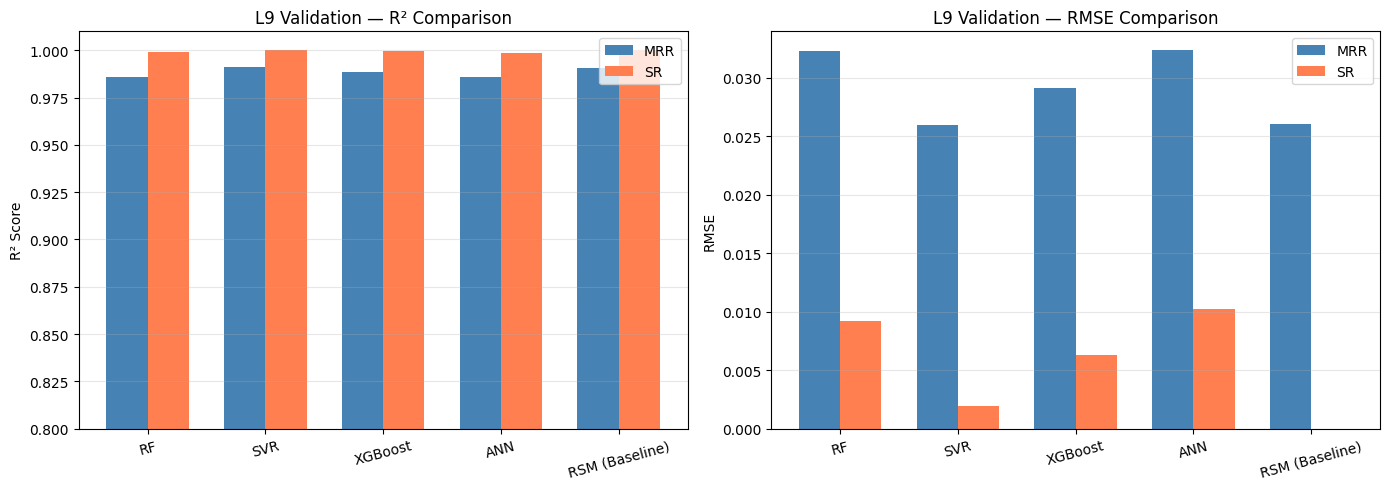

Model comparison plot saved.


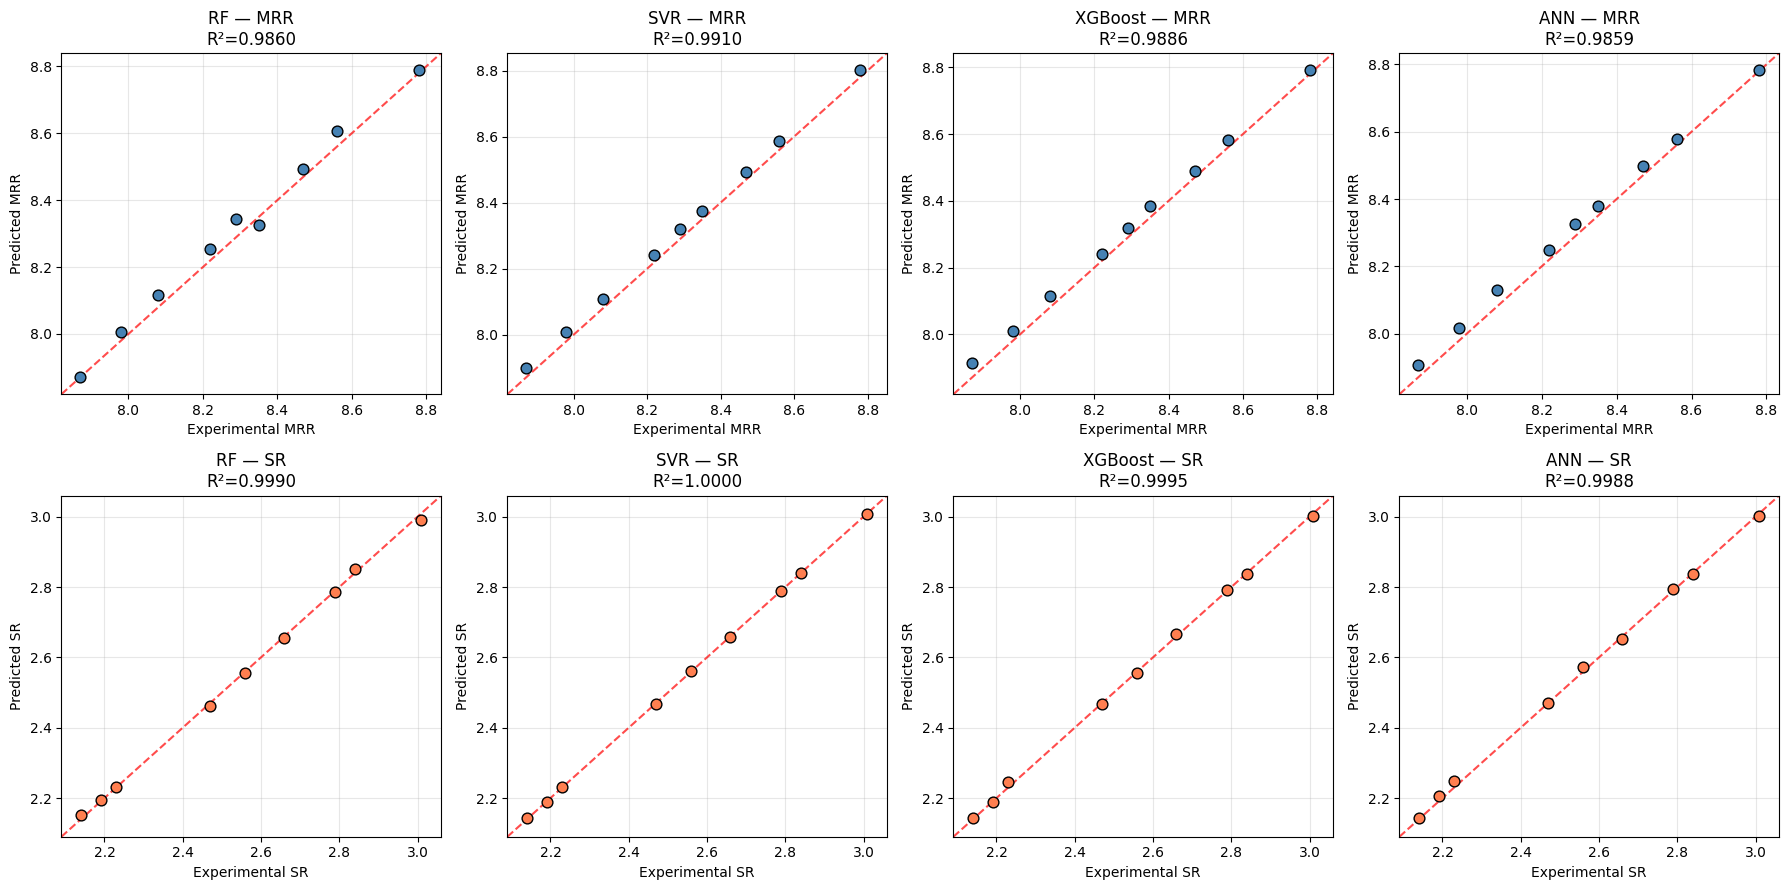

Predicted vs Actual plots saved.

NSGA-II MULTI-OBJECTIVE OPTIMIZATION

Running NSGA-II with RF surrogate...
  RF: 155 unique Pareto solutions
  MRR range: [7.7711, 8.7924]
  SR  range: [1.9602, 2.9824]

Running NSGA-II with SVR surrogate...
  SVR: 161 unique Pareto solutions
  MRR range: [7.7416, 8.8205]
  SR  range: [1.9372, 3.0125]

Running NSGA-II with XGBoost surrogate...
  XGBoost: 158 unique Pareto solutions
  MRR range: [7.7645, 8.7987]
  SR  range: [1.9592, 2.9839]

Running NSGA-II with ANN surrogate...
  ANN: 162 unique Pareto solutions
  MRR range: [7.7189, 8.7929]
  SR  range: [1.9614, 3.0030]


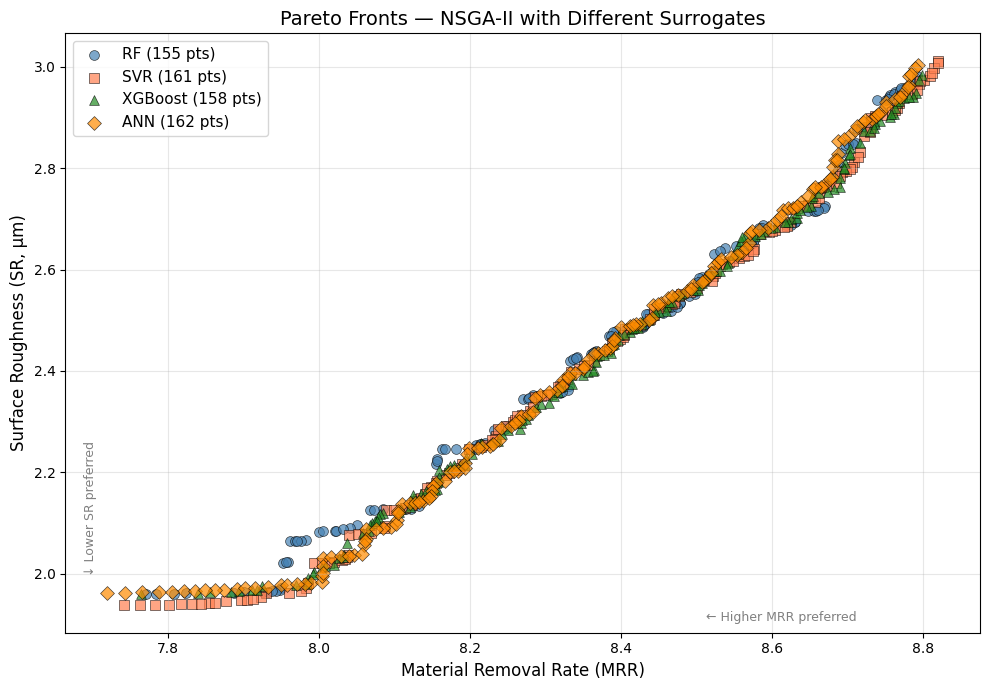

Pareto front comparison plot saved.

PARETO FRONT QUALITY METRICS
Surrogate  Hypervolume  N_solutions      MRR_range       SR_range
       RF     0.937580          155 [7.771, 8.792] [1.960, 2.982]
      SVR     0.963025          161 [7.742, 8.820] [1.937, 3.013]
  XGBoost     0.953804          158 [7.764, 8.799] [1.959, 2.984]
      ANN     0.946727          162 [7.719, 8.793] [1.961, 3.003]

TOPSIS & KNEE-POINT DECISION ANALYSIS

--- RF Surrogate ---
  TOPSIS Equal (0.5, 0.5): Ip=20, Ton=110, Toff=60, Vs=233 → MRR=7.9479, SR=1.9681 (score=0.8021)
  TOPSIS MRR-priority (0.7, 0.3): Ip=20, Ton=113, Toff=60, Vs=235 → MRR=8.1327, SR=2.1327 (score=0.6448)
  TOPSIS SR-priority (0.3, 0.7): Ip=20, Ton=110, Toff=60, Vs=233 → MRR=7.9479, SR=1.9681 (score=0.9041)
  Knee Point: Ip=20, Ton=113, Toff=60, Vs=235 → MRR=8.1327, SR=2.1327

--- SVR Surrogate ---
  TOPSIS Equal (0.5, 0.5): Ip=20, Ton=110, Toff=60, Vs=233 → MRR=7.9767, SR=1.9660 (score=0.8080)
  TOPSIS MRR-priority (0.7, 0.3): Ip=20, Ton=

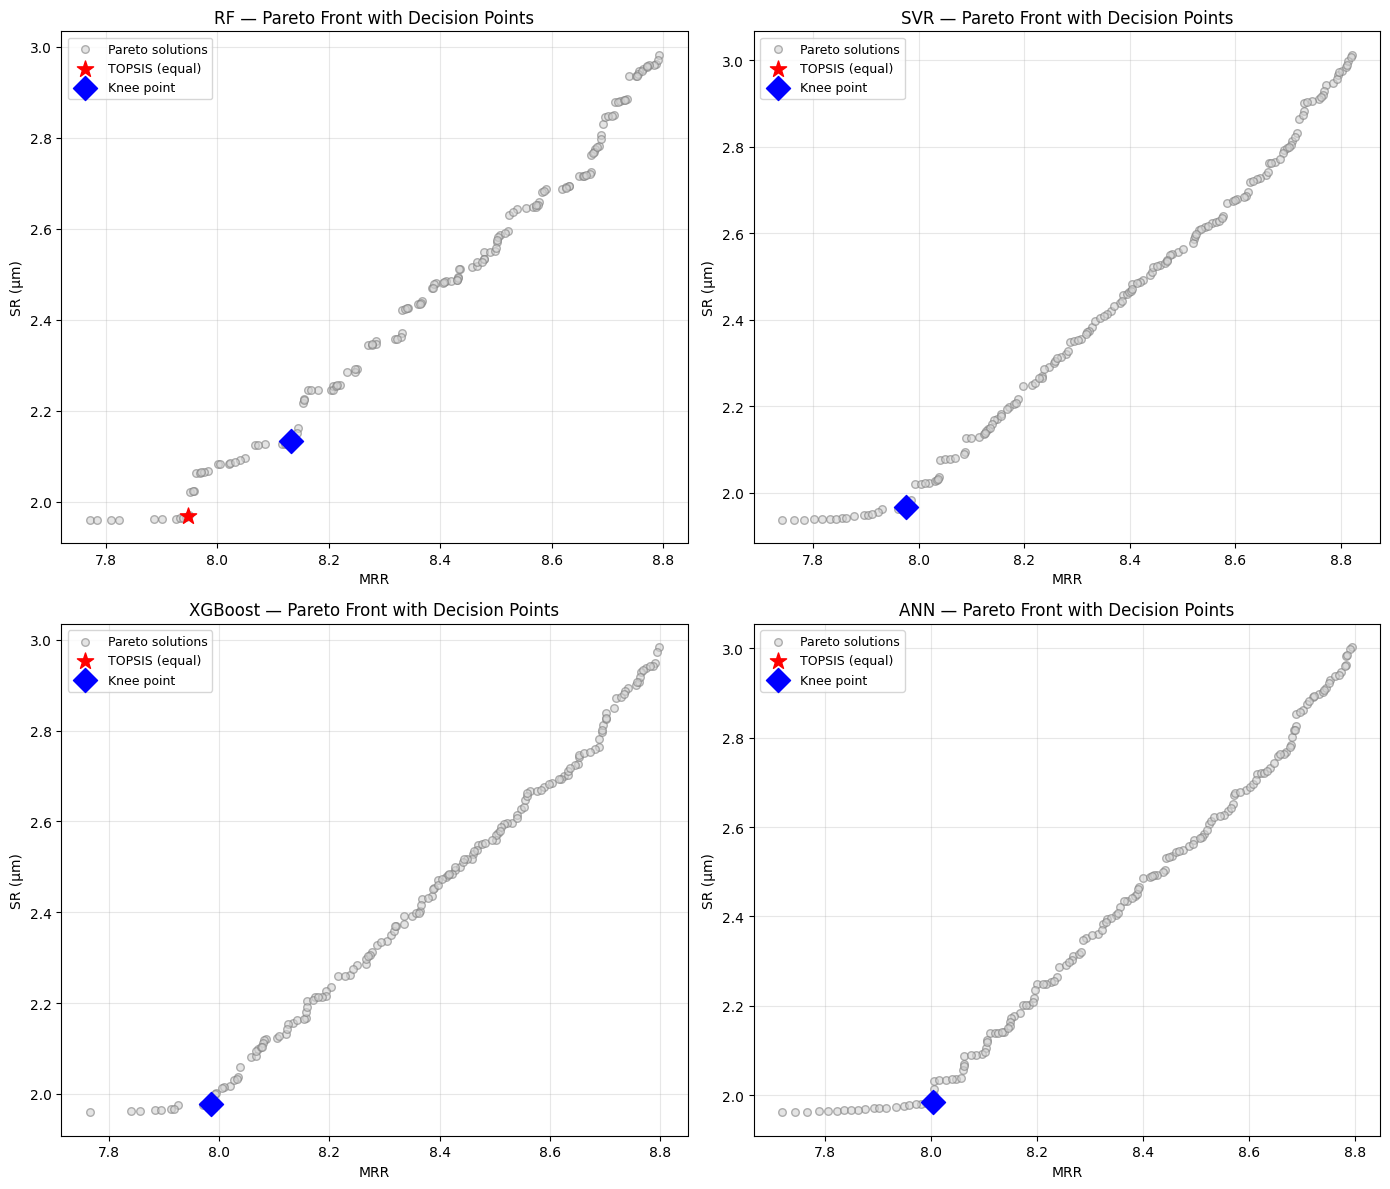

Decision analysis plots saved.

FINAL SUMMARY

1. DATASET: RSM-expanded from L9 (9 pts) to 1,100 integer points
   Parameter ranges: Ip=[20,30], Ton=[110,120], Toff=[50,60], Vs=[220,240]

2. CROSS-VALIDATION RESULTS (5-Fold on expanded dataset):
        Model  MRR_R2_mean  MRR_RMSE_mean  SR_R2_mean  SR_RMSE_mean
Random Forest       0.9737         0.0337      0.9924        0.0194
          SVR       0.9997         0.0033      0.9997        0.0038
      XGBoost       0.9917         0.0189      0.9942        0.0171
          ANN       0.9980         0.0093      0.9989        0.0075

3. EXTERNAL VALIDATION (L9 experimental data):
         Model  MRR_R2  MRR_RMSE  SR_R2  SR_RMSE
            RF  0.9860    0.0323 0.9990   0.0092
           SVR  0.9910    0.0260 1.0000   0.0020
       XGBoost  0.9886    0.0291 0.9995   0.0063
           ANN  0.9859    0.0324 0.9988   0.0102
RSM (Baseline)  0.9909    0.0261 1.0000   0.0000

4. HYPERVOLUME (larger = better Pareto front):
Surrogate  Hypervolume  

In [ ]:
#!/usr/bin/env python3
"""
=============================================================================
DATA-DRIVEN SURROGATE MODELLING AND MULTI-OBJECTIVE OPTIMIZATION
OF WEDM PROCESS PARAMETERS FOR Ti-6Al-4V ALLOY
=============================================================================
Pipeline: L9 Experimental Data → RSM Expansion (~1100 pts) → ML Surrogates
          (RF, SVR, XGBoost, ANN) → NSGA-II Optimization → TOPSIS Decision

Run in Google Colab — each section separated by clear headers.
Copy-paste sections into separate Colab cells, or run as a single script.
=============================================================================
"""

# =============================================================================
# SECTION 1: INSTALL DEPENDENCIES
# =============================================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("pymoo==0.6.1.3")
install("xgboost")
install("shap")

print("All dependencies installed.")

# =============================================================================
# SECTION 2: IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
from itertools import product

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.indicators.hv import Hypervolume

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

SAVE_DIR = "./wedm_results"
os.makedirs(SAVE_DIR, exist_ok=True)

print("All imports loaded successfully.")

# =============================================================================
# SECTION 3: DEFINE RSM EQUATIONS AND EXPERIMENTAL DATA
# =============================================================================

# --- RSM Equations from Minitab (uncoded units) ---
def rsm_mrr(Ip, Ton, Toff, Vs):
    """MRR = f(Ip, Ton, Toff, Vs) — quadratic RSM from Minitab"""
    return (-78.77
            + 0.3170 * Ip + 1.132 * Ton - 0.8390 * Toff + 0.3392 * Vs
            - 0.005267 * Ip**2 - 0.004867 * Ton**2
            + 0.007533 * Toff**2 - 0.000717 * Vs**2)

def rsm_sr(Ip, Ton, Toff, Vs):
    """SR = f(Ip, Ton, Toff, Vs) — quadratic RSM from Minitab"""
    return (-44.57
            + 0.4000 * Ip + 1.081 * Ton - 0.4140 * Toff - 0.09000 * Vs
            - 0.006800 * Ip**2 - 0.004600 * Ton**2
            + 0.003600 * Toff**2 + 0.000200 * Vs**2)

# --- Original L9 Experimental Data (ground truth for validation) ---
l9_data = pd.DataFrame({
    'Ip':   [20, 20, 20, 25, 25, 25, 30, 30, 30],
    'Ton':  [110, 115, 120, 110, 115, 120, 110, 115, 120],
    'Toff': [50, 55, 60, 55, 60, 50, 60, 50, 55],
    'Vs':   [220, 230, 240, 240, 220, 230, 230, 240, 220],
    'MRR':  [7.87, 7.98, 8.08, 8.22, 8.35, 8.56, 8.47, 8.78, 8.29],
    'SR':   [2.14, 2.19, 2.23, 2.47, 2.66, 2.84, 2.56, 3.01, 2.79]
})

# Verify RSM fits L9 data
l9_data['RSM_MRR'] = rsm_mrr(l9_data.Ip, l9_data.Ton, l9_data.Toff, l9_data.Vs)
l9_data['RSM_SR'] = rsm_sr(l9_data.Ip, l9_data.Ton, l9_data.Toff, l9_data.Vs)

print("L9 Experimental Data with RSM Predictions:")
print(l9_data.to_string(index=False))
print(f"\nRSM fit on L9 — MRR R²: {r2_score(l9_data.MRR, l9_data.RSM_MRR):.6f}")
print(f"RSM fit on L9 — SR  R²: {r2_score(l9_data.SR, l9_data.RSM_SR):.6f}")

# =============================================================================
# SECTION 4: GENERATE EXPANDED DATASET (~1100 POINTS)
# =============================================================================

# Full integer grid
ip_range   = np.arange(20, 31, 1)    # 11 values
ton_range  = np.arange(110, 121, 1)   # 11 values
toff_range = np.arange(50, 61, 1)     # 11 values
vs_range   = np.arange(220, 241, 1)   # 21 values

full_grid = np.array(list(product(ip_range, ton_range, toff_range, vs_range)))
print(f"Full integer grid size: {len(full_grid):,} points")

# Compute RSM predictions for entire grid
full_mrr = rsm_mrr(full_grid[:,0], full_grid[:,1], full_grid[:,2], full_grid[:,3])
full_sr  = rsm_sr(full_grid[:,0], full_grid[:,1], full_grid[:,2], full_grid[:,3])

# Identify the original 81 full-factorial points (3 levels each)
original_levels = {
    'Ip': [20, 25, 30], 'Ton': [110, 115, 120],
    'Toff': [50, 55, 60], 'Vs': [220, 230, 240]
}
orig_81 = np.array(list(product(
    original_levels['Ip'], original_levels['Ton'],
    original_levels['Toff'], original_levels['Vs']
)))

# Find indices of the 81 points in the full grid
orig_81_set = set(map(tuple, orig_81))
orig_indices = [i for i, row in enumerate(full_grid) if tuple(row) in orig_81_set]
remaining_indices = [i for i in range(len(full_grid)) if i not in orig_indices]

# Sample additional points to reach ~1100 total
n_additional = 1100 - len(orig_indices)
np.random.seed(42)
sampled_indices = np.random.choice(remaining_indices, size=n_additional, replace=False)

# Combine: 81 original + ~1019 sampled
selected_indices = np.array(orig_indices + list(sampled_indices))
expanded_X = full_grid[selected_indices]
expanded_mrr = full_mrr[selected_indices]
expanded_sr = full_sr[selected_indices]

# Create DataFrame
expanded_df = pd.DataFrame(expanded_X, columns=['Ip', 'Ton', 'Toff', 'Vs'])
expanded_df['MRR'] = expanded_mrr
expanded_df['SR'] = expanded_sr

# Save expanded dataset
expanded_df.to_csv(f"{SAVE_DIR}/expanded_dataset_1100.csv", index=False)

print(f"\nExpanded dataset: {len(expanded_df)} points")
print(f"  - Original 81 full-factorial points included: {len(orig_indices)}")
print(f"  - Additional sampled points: {n_additional}")
print(f"\nDataset statistics:")
print(expanded_df.describe().round(4).to_string())

# =============================================================================
# SECTION 5: DATA PREPARATION AND SCALING
# =============================================================================

feature_cols = ['Ip', 'Ton', 'Toff', 'Vs']

X_train_full = expanded_df[feature_cols].values
y_mrr_train = expanded_df['MRR'].values
y_sr_train = expanded_df['SR'].values

X_val = l9_data[feature_cols].values
y_mrr_val = l9_data['MRR'].values
y_sr_val = l9_data['SR'].values

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_full)
X_val_scaled = scaler_X.transform(X_val)

# Scale targets (needed for SVR and ANN)
scaler_mrr = StandardScaler()
scaler_sr = StandardScaler()
y_mrr_scaled = scaler_mrr.fit_transform(y_mrr_train.reshape(-1, 1)).ravel()
y_sr_scaled = scaler_sr.fit_transform(y_sr_train.reshape(-1, 1)).ravel()

# Save scalers
joblib.dump(scaler_X, f"{SAVE_DIR}/scaler_X.joblib")
joblib.dump(scaler_mrr, f"{SAVE_DIR}/scaler_mrr.joblib")
joblib.dump(scaler_sr, f"{SAVE_DIR}/scaler_sr.joblib")

print("Scalers fitted and saved.")
print(f"Training set: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Validation set (L9): {X_val_scaled.shape[0]} samples")

# =============================================================================
# SECTION 6: 5-FOLD CROSS-VALIDATION SETUP
# =============================================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(model_class, params, X, y_mrr, y_sr, model_name):
    """Run 5-fold CV and return metrics for both MRR and SR."""
    mrr_r2, mrr_rmse, sr_r2, sr_rmse = [], [], [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_mrr_tr, y_mrr_te = y_mrr[train_idx], y_mrr[test_idx]
        y_sr_tr, y_sr_te = y_sr[train_idx], y_sr[test_idx]

        # MRR model
        m_mrr = model_class(**params)
        m_mrr.fit(X_tr, y_mrr_tr)
        pred_mrr = m_mrr.predict(X_te)
        mrr_r2.append(r2_score(y_mrr_te, pred_mrr))
        mrr_rmse.append(np.sqrt(mean_squared_error(y_mrr_te, pred_mrr)))

        # SR model
        m_sr = model_class(**params)
        m_sr.fit(X_tr, y_sr_tr)
        pred_sr = m_sr.predict(X_te)
        sr_r2.append(r2_score(y_sr_te, pred_sr))
        sr_rmse.append(np.sqrt(mean_squared_error(y_sr_te, pred_sr)))

    results = {
        'Model': model_name,
        'MRR_R2_mean': np.mean(mrr_r2), 'MRR_R2_std': np.std(mrr_r2),
        'MRR_RMSE_mean': np.mean(mrr_rmse), 'MRR_RMSE_std': np.std(mrr_rmse),
        'SR_R2_mean': np.mean(sr_r2), 'SR_R2_std': np.std(sr_r2),
        'SR_RMSE_mean': np.mean(sr_rmse), 'SR_RMSE_std': np.std(sr_rmse),
    }
    print(f"\n{model_name} — 5-Fold CV Results:")
    print(f"  MRR  R² = {results['MRR_R2_mean']:.4f} ± {results['MRR_R2_std']:.4f}  "
          f"RMSE = {results['MRR_RMSE_mean']:.4f} ± {results['MRR_RMSE_std']:.4f}")
    print(f"  SR   R² = {results['SR_R2_mean']:.4f} ± {results['SR_R2_std']:.4f}  "
          f"RMSE = {results['SR_RMSE_mean']:.4f} ± {results['SR_RMSE_std']:.4f}")
    return results

# =============================================================================
# SECTION 7: TRAIN ML MODELS — RANDOM FOREST
# =============================================================================

rf_params = {
    'n_estimators': 200,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'random_state': 42,
    'n_jobs': -1
}

rf_cv = evaluate_cv(RandomForestRegressor, rf_params,
                     X_train_scaled, y_mrr_train, y_sr_train, "Random Forest")

# Train final RF models on full dataset
rf_mrr = RandomForestRegressor(**rf_params).fit(X_train_scaled, y_mrr_train)
rf_sr  = RandomForestRegressor(**rf_params).fit(X_train_scaled, y_sr_train)
joblib.dump(rf_mrr, f"{SAVE_DIR}/rf_mrr.joblib")
joblib.dump(rf_sr, f"{SAVE_DIR}/rf_sr.joblib")
print("Random Forest models saved.")

# =============================================================================
# SECTION 8: TRAIN ML MODELS — SVR
# =============================================================================

svr_params = {
    'kernel': 'rbf',
    'C': 100,
    'epsilon': 0.01,
    'gamma': 'scale'
}

svr_cv = evaluate_cv(SVR, svr_params,
                      X_train_scaled, y_mrr_scaled, y_sr_scaled, "SVR")

# Train final SVR models
svr_mrr = SVR(**svr_params).fit(X_train_scaled, y_mrr_scaled)
svr_sr  = SVR(**svr_params).fit(X_train_scaled, y_sr_scaled)
joblib.dump(svr_mrr, f"{SAVE_DIR}/svr_mrr.joblib")
joblib.dump(svr_sr, f"{SAVE_DIR}/svr_sr.joblib")
print("SVR models saved.")

# Note: SVR CV was on scaled targets — convert back for comparison
svr_cv['MRR_RMSE_mean'] *= scaler_mrr.scale_[0]
svr_cv['MRR_RMSE_std'] *= scaler_mrr.scale_[0]
svr_cv['SR_RMSE_mean'] *= scaler_sr.scale_[0]
svr_cv['SR_RMSE_std'] *= scaler_sr.scale_[0]
print(f"SVR (unscaled RMSE) — MRR: {svr_cv['MRR_RMSE_mean']:.4f}, SR: {svr_cv['SR_RMSE_mean']:.4f}")

# =============================================================================
# SECTION 9: TRAIN ML MODELS — XGBoost
# =============================================================================

xgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1
}

xgb_cv = evaluate_cv(xgb.XGBRegressor, xgb_params,
                      X_train_scaled, y_mrr_train, y_sr_train, "XGBoost")

# Train final XGBoost models
xgb_mrr = xgb.XGBRegressor(**xgb_params).fit(X_train_scaled, y_mrr_train)
xgb_sr  = xgb.XGBRegressor(**xgb_params).fit(X_train_scaled, y_sr_train)
joblib.dump(xgb_mrr, f"{SAVE_DIR}/xgb_mrr.joblib")
joblib.dump(xgb_sr, f"{SAVE_DIR}/xgb_sr.joblib")
print("XGBoost models saved.")

# =============================================================================
# SECTION 10: TRAIN ANN MODEL (v2 — FIXED)
# =============================================================================
# Changes: simpler architecture (32→16), lower dropout (0.05), lower L2 (0.0005),
# best-of-N restarts for stability, smaller batch size (16), more patience

def build_ann_v2(input_dim=4):
    model = Sequential([
        Dense(32, activation='relu', kernel_regularizer=l2(0.0005), input_shape=(input_dim,)),
        Dropout(0.05),
        Dense(16, activation='relu', kernel_regularizer=l2(0.0005)),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
                  loss='mse', metrics=['mae'])
    return model

def train_best_of_n(build_fn, X_tr, y_tr, X_te, y_te, n_restarts=3):
    """Train n_restarts models, return the one with lowest validation loss."""
    best_model = None
    best_val_loss = float('inf')
    for restart in range(n_restarts):
        tf.random.set_seed(42 + restart * 100)
        model = build_fn()
        cbs = [
            EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, min_lr=1e-6)
        ]
        model.fit(X_tr, y_tr, epochs=1000, batch_size=16,
                  validation_data=(X_te, y_te), callbacks=cbs, verbose=0)
        val_loss = model.evaluate(X_te, y_te, verbose=0)[0]
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model
    return best_model

# --- ANN 5-Fold CV ---
ann_mrr_r2, ann_mrr_rmse, ann_sr_r2, ann_sr_rmse = [], [], [], []

print("\nANN (v2) — 5-Fold Cross Validation:")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr, X_te = X_train_scaled[train_idx], X_train_scaled[test_idx]
    y_mrr_tr, y_mrr_te = y_mrr_scaled[train_idx], y_mrr_scaled[test_idx]
    y_sr_tr, y_sr_te = y_sr_scaled[train_idx], y_sr_scaled[test_idx]

    # MRR — best of 3 restarts
    m_mrr = train_best_of_n(build_ann_v2, X_tr, y_mrr_tr, X_te, y_mrr_te, n_restarts=3)
    pred_mrr_s = m_mrr.predict(X_te, verbose=0).ravel()
    pred_mrr = scaler_mrr.inverse_transform(pred_mrr_s.reshape(-1,1)).ravel()
    true_mrr = scaler_mrr.inverse_transform(y_mrr_te.reshape(-1,1)).ravel()
    ann_mrr_r2.append(r2_score(true_mrr, pred_mrr))
    ann_mrr_rmse.append(np.sqrt(mean_squared_error(true_mrr, pred_mrr)))

    # SR — best of 3 restarts
    m_sr = train_best_of_n(build_ann_v2, X_tr, y_sr_tr, X_te, y_sr_te, n_restarts=3)
    pred_sr_s = m_sr.predict(X_te, verbose=0).ravel()
    pred_sr = scaler_sr.inverse_transform(pred_sr_s.reshape(-1,1)).ravel()
    true_sr = scaler_sr.inverse_transform(y_sr_te.reshape(-1,1)).ravel()
    ann_sr_r2.append(r2_score(true_sr, pred_sr))
    ann_sr_rmse.append(np.sqrt(mean_squared_error(true_sr, pred_sr)))

    print(f"  Fold {fold+1}: MRR R²={ann_mrr_r2[-1]:.4f}, SR R²={ann_sr_r2[-1]:.4f}")

ann_cv = {
    'Model': 'ANN',
    'MRR_R2_mean': np.mean(ann_mrr_r2), 'MRR_R2_std': np.std(ann_mrr_r2),
    'MRR_RMSE_mean': np.mean(ann_mrr_rmse), 'MRR_RMSE_std': np.std(ann_mrr_rmse),
    'SR_R2_mean': np.mean(ann_sr_r2), 'SR_R2_std': np.std(ann_sr_r2),
    'SR_RMSE_mean': np.mean(ann_sr_rmse), 'SR_RMSE_std': np.std(ann_sr_rmse),
}
print(f"\nANN (v2) — 5-Fold CV Results:")
print(f"  MRR  R² = {ann_cv['MRR_R2_mean']:.4f} ± {ann_cv['MRR_R2_std']:.4f}  "
      f"RMSE = {ann_cv['MRR_RMSE_mean']:.4f} ± {ann_cv['MRR_RMSE_std']:.4f}")
print(f"  SR   R² = {ann_cv['SR_R2_mean']:.4f} ± {ann_cv['SR_R2_std']:.4f}  "
      f"RMSE = {ann_cv['SR_RMSE_mean']:.4f} ± {ann_cv['SR_RMSE_std']:.4f}")

# Train final ANN models (best of 5 restarts)
print("\nTraining final ANN models (best of 5 restarts)...")
from sklearn.model_selection import train_test_split
X_tr_f, X_ho_f, y_mrr_tr_f, y_mrr_ho_f = train_test_split(
    X_train_scaled, y_mrr_scaled, test_size=0.1, random_state=42)
_, _, y_sr_tr_f, y_sr_ho_f = train_test_split(
    X_train_scaled, y_sr_scaled, test_size=0.1, random_state=42)

ann_mrr_final = train_best_of_n(build_ann_v2, X_tr_f, y_mrr_tr_f,
                                 X_ho_f, y_mrr_ho_f, n_restarts=5)
ann_sr_final = train_best_of_n(build_ann_v2, X_tr_f, y_sr_tr_f,
                                X_ho_f, y_sr_ho_f, n_restarts=5)

ann_mrr_final.save(f"{SAVE_DIR}/ann_mrr.keras")
ann_sr_final.save(f"{SAVE_DIR}/ann_sr.keras")
print("ANN (v2) models saved.")

# Quick L9 validation check
ann_check_mrr = scaler_mrr.inverse_transform(
    ann_mrr_final.predict(X_val_scaled, verbose=0)).ravel()
ann_check_sr = scaler_sr.inverse_transform(
    ann_sr_final.predict(X_val_scaled, verbose=0)).ravel()
print(f"ANN L9 validation check: MRR R²={r2_score(y_mrr_val, ann_check_mrr):.4f}, "
      f"SR R²={r2_score(y_sr_val, ann_check_sr):.4f}")

# =============================================================================
# SECTION 11: EXTERNAL VALIDATION ON L9 EXPERIMENTAL DATA
# =============================================================================

print("\n" + "="*70)
print("EXTERNAL VALIDATION ON L9 EXPERIMENTAL DATA (9 points)")
print("="*70)

validation_results = []

# --- RF ---
rf_pred_mrr = rf_mrr.predict(X_val_scaled)
rf_pred_sr  = rf_sr.predict(X_val_scaled)
validation_results.append({
    'Model': 'RF',
    'MRR_R2': r2_score(y_mrr_val, rf_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, rf_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, rf_pred_mrr),
    'SR_R2': r2_score(y_sr_val, rf_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, rf_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, rf_pred_sr),
})

# --- SVR (predict on scaled, inverse transform) ---
svr_pred_mrr = scaler_mrr.inverse_transform(svr_mrr.predict(X_val_scaled).reshape(-1,1)).ravel()
svr_pred_sr  = scaler_sr.inverse_transform(svr_sr.predict(X_val_scaled).reshape(-1,1)).ravel()
validation_results.append({
    'Model': 'SVR',
    'MRR_R2': r2_score(y_mrr_val, svr_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, svr_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, svr_pred_mrr),
    'SR_R2': r2_score(y_sr_val, svr_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, svr_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, svr_pred_sr),
})

# --- XGBoost ---
xgb_pred_mrr = xgb_mrr.predict(X_val_scaled)
xgb_pred_sr  = xgb_sr.predict(X_val_scaled)
validation_results.append({
    'Model': 'XGBoost',
    'MRR_R2': r2_score(y_mrr_val, xgb_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, xgb_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, xgb_pred_mrr),
    'SR_R2': r2_score(y_sr_val, xgb_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, xgb_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, xgb_pred_sr),
})

# --- ANN ---
ann_pred_mrr = scaler_mrr.inverse_transform(
    ann_mrr_final.predict(X_val_scaled, verbose=0)).ravel()
ann_pred_sr = scaler_sr.inverse_transform(
    ann_sr_final.predict(X_val_scaled, verbose=0)).ravel()
validation_results.append({
    'Model': 'ANN',
    'MRR_R2': r2_score(y_mrr_val, ann_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, ann_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, ann_pred_mrr),
    'SR_R2': r2_score(y_sr_val, ann_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, ann_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, ann_pred_sr),
})

# --- RSM baseline ---
rsm_pred_mrr = rsm_mrr(X_val[:,0], X_val[:,1], X_val[:,2], X_val[:,3])
rsm_pred_sr  = rsm_sr(X_val[:,0], X_val[:,1], X_val[:,2], X_val[:,3])
validation_results.append({
    'Model': 'RSM (Baseline)',
    'MRR_R2': r2_score(y_mrr_val, rsm_pred_mrr),
    'MRR_RMSE': np.sqrt(mean_squared_error(y_mrr_val, rsm_pred_mrr)),
    'MRR_MAE': mean_absolute_error(y_mrr_val, rsm_pred_mrr),
    'SR_R2': r2_score(y_sr_val, rsm_pred_sr),
    'SR_RMSE': np.sqrt(mean_squared_error(y_sr_val, rsm_pred_sr)),
    'SR_MAE': mean_absolute_error(y_sr_val, rsm_pred_sr),
})

val_df = pd.DataFrame(validation_results)
print(val_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
val_df.to_csv(f"{SAVE_DIR}/validation_results.csv", index=False)

# =============================================================================
# SECTION 12: CV COMPARISON TABLE
# =============================================================================

cv_df = pd.DataFrame([rf_cv, svr_cv, xgb_cv, ann_cv])
print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION COMPARISON")
print("="*70)
print(cv_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
cv_df.to_csv(f"{SAVE_DIR}/cv_results.csv", index=False)

# =============================================================================
# SECTION 13: VISUALIZATION — MODEL COMPARISON
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: R² comparison on L9 validation
models_names = val_df['Model'].tolist()
x_pos = np.arange(len(models_names))
width = 0.35

axes[0].bar(x_pos - width/2, val_df['MRR_R2'], width, label='MRR', color='steelblue')
axes[0].bar(x_pos + width/2, val_df['SR_R2'], width, label='SR', color='coral')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_names, rotation=15)
axes[0].set_ylabel('R² Score')
axes[0].set_title('L9 Validation — R² Comparison')
axes[0].legend()
axes[0].set_ylim(0.8, 1.01)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart: RMSE comparison on L9 validation
axes[1].bar(x_pos - width/2, val_df['MRR_RMSE'], width, label='MRR', color='steelblue')
axes[1].bar(x_pos + width/2, val_df['SR_RMSE'], width, label='SR', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_names, rotation=15)
axes[1].set_ylabel('RMSE')
axes[1].set_title('L9 Validation — RMSE Comparison')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison plot saved.")

# =============================================================================
# SECTION 14: PREDICTED vs ACTUAL PLOTS (L9 VALIDATION)
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

all_preds = {
    'RF':      (rf_pred_mrr, rf_pred_sr),
    'SVR':     (svr_pred_mrr, svr_pred_sr),
    'XGBoost': (xgb_pred_mrr, xgb_pred_sr),
    'ANN':     (ann_pred_mrr, ann_pred_sr),
}

for idx, (name, (p_mrr, p_sr)) in enumerate(all_preds.items()):
    # MRR
    ax = axes[0, idx]
    ax.scatter(y_mrr_val, p_mrr, c='steelblue', edgecolors='k', s=60, zorder=3)
    lims = [min(y_mrr_val.min(), p_mrr.min())-0.05, max(y_mrr_val.max(), p_mrr.max())+0.05]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental MRR'); ax.set_ylabel('Predicted MRR')
    ax.set_title(f'{name} — MRR\nR²={r2_score(y_mrr_val, p_mrr):.4f}')
    ax.grid(alpha=0.3)

    # SR
    ax = axes[1, idx]
    ax.scatter(y_sr_val, p_sr, c='coral', edgecolors='k', s=60, zorder=3)
    lims = [min(y_sr_val.min(), p_sr.min())-0.05, max(y_sr_val.max(), p_sr.max())+0.05]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental SR'); ax.set_ylabel('Predicted SR')
    ax.set_title(f'{name} — SR\nR²={r2_score(y_sr_val, p_sr):.4f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()
print("Predicted vs Actual plots saved.")

# =============================================================================
# SECTION 15: NSGA-II OPTIMIZATION — PROBLEM DEFINITION
# =============================================================================

# Parameter bounds (integer)
BOUNDS_LOWER = np.array([20, 110, 50, 220])
BOUNDS_UPPER = np.array([30, 120, 60, 240])

class WEDMProblem(Problem):
    """
    Multi-objective: minimize(-MRR) and minimize(SR)
    Integer constraints enforced by rounding.
    """
    def __init__(self, predict_mrr_fn, predict_sr_fn, name=""):
        super().__init__(
            n_var=4, n_obj=2,
            xl=BOUNDS_LOWER.astype(float),
            xu=BOUNDS_UPPER.astype(float)
        )
        self.predict_mrr = predict_mrr_fn
        self.predict_sr = predict_sr_fn
        self.surrogate_name = name

    def _evaluate(self, X, out, *args, **kwargs):
        # Enforce integer constraints
        X_int = np.round(X).astype(float)
        X_int = np.clip(X_int, self.xl, self.xu)

        mrr = self.predict_mrr(X_int)
        sr  = self.predict_sr(X_int)

        # Minimize: -MRR (to maximize MRR) and SR
        out["F"] = np.column_stack([-mrr, sr])

# --- Prediction functions for each surrogate ---
def make_rf_predictor():
    def pred_mrr(X):
        return rf_mrr.predict(scaler_X.transform(X))
    def pred_sr(X):
        return rf_sr.predict(scaler_X.transform(X))
    return pred_mrr, pred_sr

def make_svr_predictor():
    def pred_mrr(X):
        return scaler_mrr.inverse_transform(
            svr_mrr.predict(scaler_X.transform(X)).reshape(-1,1)).ravel()
    def pred_sr(X):
        return scaler_sr.inverse_transform(
            svr_sr.predict(scaler_X.transform(X)).reshape(-1,1)).ravel()
    return pred_mrr, pred_sr

def make_xgb_predictor():
    def pred_mrr(X):
        return xgb_mrr.predict(scaler_X.transform(X))
    def pred_sr(X):
        return xgb_sr.predict(scaler_X.transform(X))
    return pred_mrr, pred_sr

def make_ann_predictor():
    def pred_mrr(X):
        return scaler_mrr.inverse_transform(
            ann_mrr_final.predict(scaler_X.transform(X), verbose=0)).ravel()
    def pred_sr(X):
        return scaler_sr.inverse_transform(
            ann_sr_final.predict(scaler_X.transform(X), verbose=0)).ravel()
    return pred_mrr, pred_sr

# =============================================================================
# SECTION 16: RUN NSGA-II FOR ALL SURROGATES
# =============================================================================

nsga2_config = NSGA2(
    pop_size=200,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

surrogates = {
    'RF':      make_rf_predictor(),
    'SVR':     make_svr_predictor(),
    'XGBoost': make_xgb_predictor(),
    'ANN':     make_ann_predictor(),
}

pareto_results = {}
all_pareto_dfs = []

print("\n" + "="*70)
print("NSGA-II MULTI-OBJECTIVE OPTIMIZATION")
print("="*70)

for name, (pred_mrr_fn, pred_sr_fn) in surrogates.items():
    print(f"\nRunning NSGA-II with {name} surrogate...")

    problem = WEDMProblem(pred_mrr_fn, pred_sr_fn, name=name)

    result = pymoo_minimize(
        problem,
        nsga2_config,
        ('n_gen', 300),
        seed=42,
        verbose=False
    )

    # Extract Pareto front — convert back to original objectives
    F = result.F.copy()
    F[:, 0] = -F[:, 0]  # Convert -MRR back to MRR

    # Extract decision variables (round to integers)
    X_opt = np.round(result.X).astype(int)
    X_opt = np.clip(X_opt, BOUNDS_LOWER, BOUNDS_UPPER)

    # Build results DataFrame
    pareto_df = pd.DataFrame(X_opt, columns=['Ip', 'Ton', 'Toff', 'Vs'])
    pareto_df['MRR'] = F[:, 0]
    pareto_df['SR']  = F[:, 1]
    pareto_df['Surrogate'] = name

    # Remove duplicates (from integer rounding)
    pareto_df = pareto_df.drop_duplicates(subset=['Ip','Ton','Toff','Vs']).reset_index(drop=True)

    pareto_results[name] = pareto_df
    all_pareto_dfs.append(pareto_df)

    pareto_df.to_csv(f"{SAVE_DIR}/pareto_{name}.csv", index=False)

    print(f"  {name}: {len(pareto_df)} unique Pareto solutions")
    print(f"  MRR range: [{pareto_df.MRR.min():.4f}, {pareto_df.MRR.max():.4f}]")
    print(f"  SR  range: [{pareto_df.SR.min():.4f}, {pareto_df.SR.max():.4f}]")

# Combine all Pareto solutions
combined_pareto = pd.concat(all_pareto_dfs, ignore_index=True)
combined_pareto.to_csv(f"{SAVE_DIR}/all_pareto_solutions.csv", index=False)

# =============================================================================
# SECTION 17: PARETO FRONT VISUALIZATION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7))
colors = {'RF': 'steelblue', 'SVR': 'coral', 'XGBoost': 'forestgreen', 'ANN': 'darkorange'}
markers = {'RF': 'o', 'SVR': 's', 'XGBoost': '^', 'ANN': 'D'}

for name, pdf in pareto_results.items():
    ax.scatter(pdf['MRR'], pdf['SR'], c=colors[name], marker=markers[name],
               label=f'{name} ({len(pdf)} pts)', alpha=0.7, edgecolors='k',
               linewidths=0.5, s=50)

ax.set_xlabel('Material Removal Rate (MRR)', fontsize=12)
ax.set_ylabel('Surface Roughness (SR, µm)', fontsize=12)
ax.set_title('Pareto Fronts — NSGA-II with Different Surrogates', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.annotate('← Higher MRR preferred', xy=(0.7, 0.02), xycoords='axes fraction',
            fontsize=9, color='gray')
ax.annotate('↓ Lower SR preferred', xy=(0.02, 0.1), xycoords='axes fraction',
            fontsize=9, color='gray', rotation=90)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pareto_fronts_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Pareto front comparison plot saved.")

# =============================================================================
# SECTION 18: HYPERVOLUME COMPARISON
# =============================================================================

print("\n" + "="*70)
print("PARETO FRONT QUALITY METRICS")
print("="*70)

# Reference point for hypervolume: worst possible objectives
# For minimization form: reference = [max(-MRR), max(SR)] = [-min(MRR), max(SR)]
all_mrr = combined_pareto['MRR'].values
all_sr  = combined_pareto['SR'].values
ref_point = np.array([-all_mrr.min() + 0.1, all_sr.max() + 0.1])

hv_metric = Hypervolume(ref_point=ref_point)

hv_results = []
for name, pdf in pareto_results.items():
    F_min = np.column_stack([-pdf['MRR'].values, pdf['SR'].values])
    hv = hv_metric(F_min)
    hv_results.append({'Surrogate': name, 'Hypervolume': hv, 'N_solutions': len(pdf),
                       'MRR_range': f"[{pdf.MRR.min():.3f}, {pdf.MRR.max():.3f}]",
                       'SR_range': f"[{pdf.SR.min():.3f}, {pdf.SR.max():.3f}]"})

hv_df = pd.DataFrame(hv_results)
print(hv_df.to_string(index=False))
hv_df.to_csv(f"{SAVE_DIR}/hypervolume_comparison.csv", index=False)

# =============================================================================
# SECTION 19: TOPSIS DECISION ANALYSIS
# =============================================================================

def topsis(decision_matrix, weights, benefit_criteria):
    """
    TOPSIS: Technique for Order of Preference by Similarity to Ideal Solution.
    decision_matrix: (n_solutions, n_criteria)
    weights: array of criterion weights (sum to 1)
    benefit_criteria: boolean array (True = maximize, False = minimize)
    """
    # Normalize
    norm = np.sqrt((decision_matrix**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    R = decision_matrix / norm

    # Weighted normalized
    V = R * weights

    # Ideal and anti-ideal
    ideal = np.where(benefit_criteria, V.max(axis=0), V.min(axis=0))
    anti_ideal = np.where(benefit_criteria, V.min(axis=0), V.max(axis=0))

    # Distances
    d_pos = np.sqrt(((V - ideal)**2).sum(axis=1))
    d_neg = np.sqrt(((V - anti_ideal)**2).sum(axis=1))

    # Closeness coefficient
    C = d_neg / (d_pos + d_neg + 1e-10)
    return C

def geometric_knee_point(pareto_df):
    """Find the geometric knee point — max perpendicular distance from line
    connecting extreme Pareto solutions."""
    mrr = pareto_df['MRR'].values
    sr = pareto_df['SR'].values

    # Normalize to [0,1]
    mrr_n = (mrr - mrr.min()) / (mrr.max() - mrr.min() + 1e-10)
    sr_n = (sr - sr.min()) / (sr.max() - sr.min() + 1e-10)

    # Line from (0,1) to (1,0) in normalized space
    # Point: (mrr_n, sr_n), Line: x + y = 1 → distance = |x + y - 1| / sqrt(2)
    distances = np.abs(mrr_n + sr_n - 1) / np.sqrt(2)

    # For Pareto front with trade-off, knee is the point closest to the line
    # connecting the extremes. Actually, it's the point with max distance from
    # the line connecting the two extreme points of the front.
    # Let's use the line connecting min-SR and max-MRR endpoints
    idx_max_mrr = np.argmax(mrr_n)
    idx_min_sr  = np.argmin(sr_n)
    p1 = np.array([mrr_n[idx_max_mrr], sr_n[idx_max_mrr]])
    p2 = np.array([mrr_n[idx_min_sr], sr_n[idx_min_sr]])

    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    if line_len < 1e-10:
        return 0

    perp_dist = []
    for i in range(len(mrr_n)):
        pt = np.array([mrr_n[i], sr_n[i]])
        d = np.abs(np.cross(line_vec, p1 - pt)) / line_len
        perp_dist.append(d)

    return np.argmax(perp_dist)

# Weight schemes for TOPSIS
weight_schemes = {
    'Equal (0.5, 0.5)':          np.array([0.5, 0.5]),
    'MRR-priority (0.7, 0.3)':   np.array([0.7, 0.3]),
    'SR-priority (0.3, 0.7)':    np.array([0.3, 0.7]),
}
benefit_criteria = np.array([True, False])  # Max MRR, Min SR

print("\n" + "="*70)
print("TOPSIS & KNEE-POINT DECISION ANALYSIS")
print("="*70)

best_solutions = []

for surr_name, pdf in pareto_results.items():
    print(f"\n--- {surr_name} Surrogate ---")
    dm = pdf[['MRR', 'SR']].values

    for scheme_name, weights in weight_schemes.items():
        scores = topsis(dm, weights, benefit_criteria)
        best_idx = np.argmax(scores)
        sol = pdf.iloc[best_idx]
        print(f"  TOPSIS {scheme_name}: Ip={sol.Ip:.0f}, Ton={sol.Ton:.0f}, "
              f"Toff={sol.Toff:.0f}, Vs={sol.Vs:.0f} → MRR={sol.MRR:.4f}, SR={sol.SR:.4f} "
              f"(score={scores[best_idx]:.4f})")
        best_solutions.append({
            'Surrogate': surr_name, 'Method': f'TOPSIS {scheme_name}',
            'Ip': sol.Ip, 'Ton': sol.Ton, 'Toff': sol.Toff, 'Vs': sol.Vs,
            'MRR': sol.MRR, 'SR': sol.SR, 'Score': scores[best_idx]
        })

    # Knee point
    knee_idx = geometric_knee_point(pdf)
    sol = pdf.iloc[knee_idx]
    print(f"  Knee Point: Ip={sol.Ip:.0f}, Ton={sol.Ton:.0f}, "
          f"Toff={sol.Toff:.0f}, Vs={sol.Vs:.0f} → MRR={sol.MRR:.4f}, SR={sol.SR:.4f}")
    best_solutions.append({
        'Surrogate': surr_name, 'Method': 'Geometric Knee',
        'Ip': sol.Ip, 'Ton': sol.Ton, 'Toff': sol.Toff, 'Vs': sol.Vs,
        'MRR': sol.MRR, 'SR': sol.SR, 'Score': np.nan
    })

best_df = pd.DataFrame(best_solutions)
best_df.to_csv(f"{SAVE_DIR}/best_solutions.csv", index=False)

# =============================================================================
# SECTION 20: PARETO FRONTS WITH DECISION POINTS HIGHLIGHTED
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (name, pdf) in enumerate(pareto_results.items()):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(pdf['MRR'], pdf['SR'], c='lightgray', edgecolors='gray',
               s=30, alpha=0.6, label='Pareto solutions')

    # Highlight TOPSIS equal-weight solution
    dm = pdf[['MRR', 'SR']].values
    eq_scores = topsis(dm, np.array([0.5, 0.5]), benefit_criteria)
    eq_idx = np.argmax(eq_scores)
    ax.scatter(pdf.iloc[eq_idx].MRR, pdf.iloc[eq_idx].SR, c='red', s=150,
               marker='*', zorder=5, label='TOPSIS (equal)')

    # Highlight knee point
    knee_idx = geometric_knee_point(pdf)
    ax.scatter(pdf.iloc[knee_idx].MRR, pdf.iloc[knee_idx].SR, c='blue', s=150,
               marker='D', zorder=5, label='Knee point')

    ax.set_xlabel('MRR')
    ax.set_ylabel('SR (µm)')
    ax.set_title(f'{name} — Pareto Front with Decision Points')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pareto_with_decisions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Decision analysis plots saved.")

# =============================================================================
# SECTION 21: FINAL SUMMARY
# =============================================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\n1. DATASET: RSM-expanded from L9 (9 pts) to 1,100 integer points")
print(f"   Parameter ranges: Ip=[20,30], Ton=[110,120], Toff=[50,60], Vs=[220,240]")

print("\n2. CROSS-VALIDATION RESULTS (5-Fold on expanded dataset):")
print(cv_df[['Model','MRR_R2_mean','MRR_RMSE_mean','SR_R2_mean','SR_RMSE_mean']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"))

print("\n3. EXTERNAL VALIDATION (L9 experimental data):")
print(val_df[['Model','MRR_R2','MRR_RMSE','SR_R2','SR_RMSE']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"))

print("\n4. HYPERVOLUME (larger = better Pareto front):")
print(hv_df[['Surrogate','Hypervolume','N_solutions']].to_string(index=False))

print("\n5. RECOMMENDED SOLUTIONS (TOPSIS equal weights):")
eq_solutions = best_df[best_df['Method'] == 'TOPSIS Equal (0.5, 0.5)']
print(eq_solutions[['Surrogate','Ip','Ton','Toff','Vs','MRR','SR']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

print(f"\nAll results saved to: {SAVE_DIR}/")
print("Files: expanded_dataset_1100.csv, validation_results.csv, cv_results.csv,")
print("       pareto_*.csv, all_pareto_solutions.csv, hypervolume_comparison.csv,")
print("       best_solutions.csv, + all plots (.png) and models (.joblib/.keras)")
print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)

PATHWAY 2: GAUSSIAN PROCESS REGRESSION — DIRECT ML ON 9 POINTS
Training data: 9 experimental points, 4 features
MRR range: [7.87, 8.78]
SR  range: [2.14, 3.01]

Training GPR models on 9 experimental points...

  GPR-MRR — Best kernel: RBF
  Log-marginal-likelihood: -10.7047
  Optimized kernel: 1.19**2 * RBF(length_scale=[0.853, 3.35, 100, 2.56]) + WhiteKernel(noise_level=2.16e-09)
  Training R²: 1.000000

  GPR-SR — Best kernel: RBF
  Log-marginal-likelihood: -9.6968
  Optimized kernel: 1.22**2 * RBF(length_scale=[0.876, 4.22, 4.02, 6.31]) + WhiteKernel(noise_level=2.73e-09)
  Training R²: 1.000000

GPR models saved.

GPR LEAVE-ONE-OUT CROSS-VALIDATION (9 folds)

GPR LOO-CV Results:
  MRR — R²: -1.1861, RMSE: 0.4036, MAE: 0.3667
  SR  — R²: -0.7245, RMSE: 0.3845, MAE: 0.3458

Detailed LOO predictions:
 Ip  Ton  Toff  Vs    MRR  MRR_pred  MRR_std     SR  SR_pred  SR_std
 20  110    50 220 7.8700    8.1566   0.1866 2.1400   2.5014  0.1519
 20  115    55 230 7.9800    8.5962   0.0941 2.19

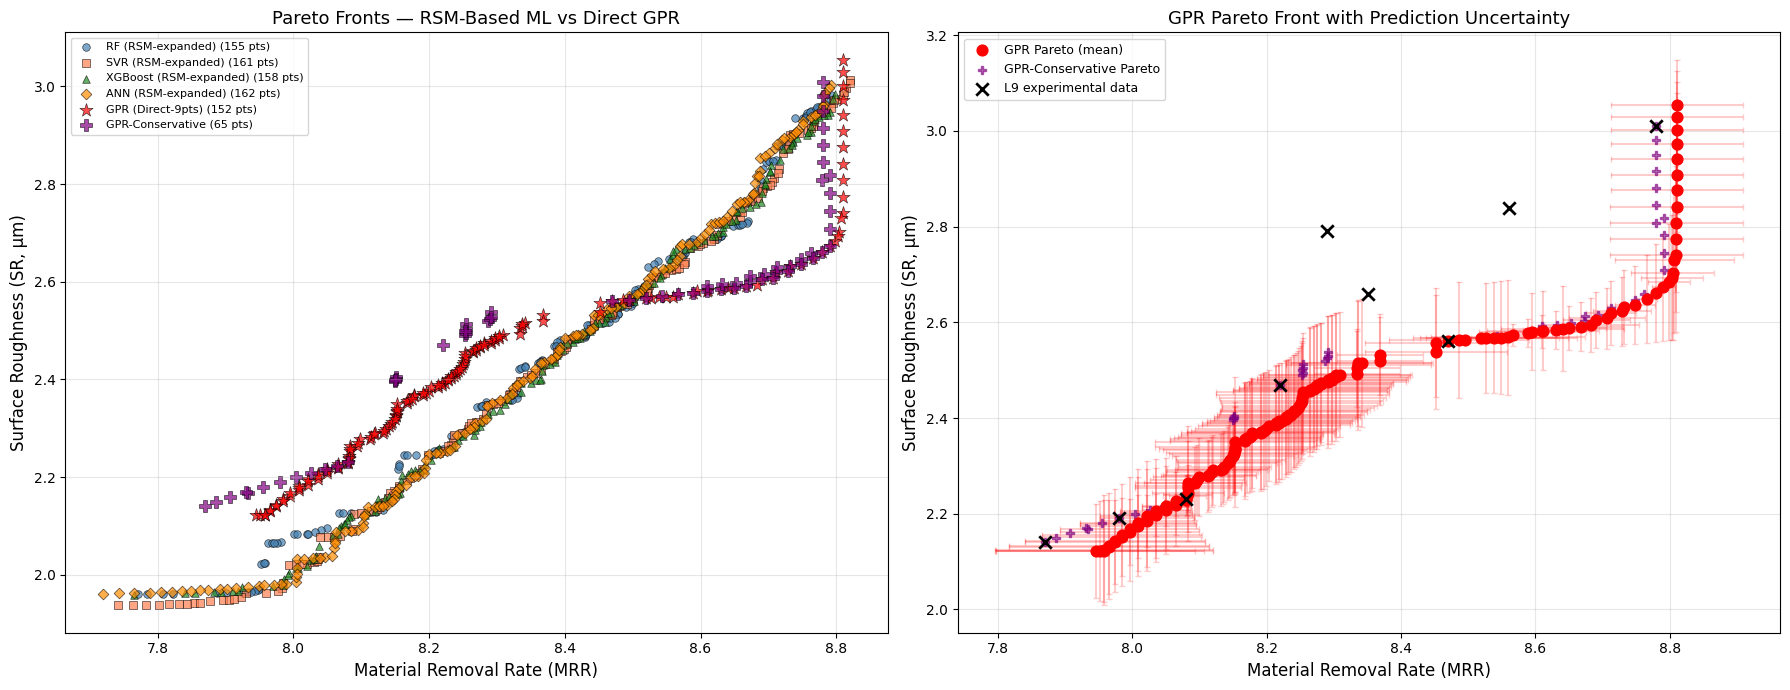

Comparison plot saved.

TOPSIS DECISION ANALYSIS — GPR SURROGATE
  TOPSIS Equal (0.5, 0.5): Ip=20, Ton=110, Toff=52, Vs=240 → MRR=7.9578 ± 0.1622, SR=2.1219 ± 0.1063
  TOPSIS MRR-priority (0.7, 0.3): Ip=20, Ton=120, Toff=59, Vs=240 → MRR=8.0800 ± 0.0008, SR=2.2293 ± 0.0154
  TOPSIS SR-priority (0.3, 0.7): Ip=20, Ton=110, Toff=52, Vs=240 → MRR=7.9578 ± 0.1622, SR=2.1219 ± 0.1063

GPR vs RSM RESPONSE SURFACE COMPARISON
GPR vs RSM on 81-point grid:
  MRR — Mean diff: -0.0213, Max |diff|: 0.3507
  SR  — Mean diff: 0.0046, Max |diff|: 0.2449
  MRR correlation (GPR vs RSM): 0.8394
  SR  correlation (GPR vs RSM): 0.9299


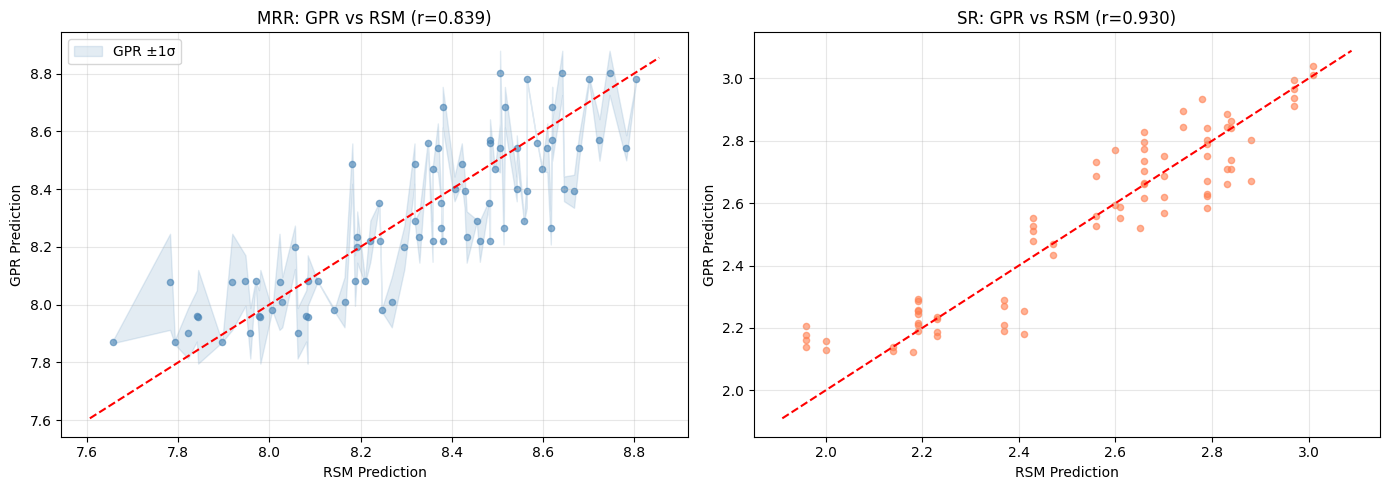

Surface comparison plot saved.

PATHWAY 2 SUMMARY — GPR DIRECT ML

1. MODEL: GPR trained directly on 9 L9 experimental points
   - No RSM expansion needed
   - Automatic kernel optimization (Matern/RBF)
   - Captures nonlinear interactions via kernel function

2. VALIDATION (LOO-CV):
   MRR — R²: -1.1861, RMSE: 0.4036
   SR  — R²: -0.7245, RMSE: 0.3845

3. KEY ADVANTAGE: Uncertainty quantification
   Average prediction uncertainty:
   MRR: ±0.0865
   SR:  ±0.0978

4. PARETO FRONT:
   GPR (mean): 152 solutions
   GPR (conservative): 65 solutions

5. COMPARISON WITH RSM-BASED ML:
   GPR captures similar overall trend but with uncertainty awareness
   Unlike RSM-based models, GPR honestly reports where predictions are reliable

6. FILES SAVED:
   gpr_mrr.joblib, gpr_sr.joblib, scaler_gpr.joblib
   gpr_loo_cv_results.csv, pareto_GPR.csv, pareto_GPR_conservative.csv
   best_solutions_GPR.csv, hypervolume_comparison_all.csv
   pareto_GPR_vs_RSM_comparison.png, gpr_vs_rsm_surface.png

PATHWAY

In [ ]:
# =============================================================================
# PATHWAY 2: GAUSSIAN PROCESS REGRESSION — DIRECT ML ON 9 EXPERIMENTAL POINTS
# =============================================================================
# Run this AFTER the main pipeline (Sections 1-9 already executed)
# This adds GPR as a 5th surrogate trained directly on L9 data — no RSM expansion
# =============================================================================

# --- Install if needed ---
# pip install scikit-learn  (already installed from main pipeline)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.indicators.hv import Hypervolume
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

SAVE_DIR = "./wedm_results"
os.makedirs(SAVE_DIR, exist_ok=True)

print("="*70)
print("PATHWAY 2: GAUSSIAN PROCESS REGRESSION — DIRECT ML ON 9 POINTS")
print("="*70)

# =============================================================================
# STEP 1: LOAD L9 EXPERIMENTAL DATA (SAME AS MAIN PIPELINE)
# =============================================================================

l9_data = pd.DataFrame({
    'Ip':   [20, 20, 20, 25, 25, 25, 30, 30, 30],
    'Ton':  [110, 115, 120, 110, 115, 120, 110, 115, 120],
    'Toff': [50, 55, 60, 55, 60, 50, 60, 50, 55],
    'Vs':   [220, 230, 240, 240, 220, 230, 230, 240, 220],
    'MRR':  [7.87, 7.98, 8.08, 8.22, 8.35, 8.56, 8.47, 8.78, 8.29],
    'SR':   [2.14, 2.19, 2.23, 2.47, 2.66, 2.84, 2.56, 3.01, 2.79]
})

feature_cols = ['Ip', 'Ton', 'Toff', 'Vs']
X_raw = l9_data[feature_cols].values
y_mrr = l9_data['MRR'].values
y_sr = l9_data['SR'].values

# Scale features for GPR
scaler_gpr = StandardScaler()
X_scaled = scaler_gpr.fit_transform(X_raw)

print(f"Training data: {X_scaled.shape[0]} experimental points, {X_scaled.shape[1]} features")
print(f"MRR range: [{y_mrr.min():.2f}, {y_mrr.max():.2f}]")
print(f"SR  range: [{y_sr.min():.2f}, {y_sr.max():.2f}]")

# =============================================================================
# STEP 2: TRAIN GPR MODELS WITH OPTIMIZED KERNELS
# =============================================================================

# Kernel: ConstantKernel * Matern + WhiteKernel
# Matern nu=2.5 is flexible (between RBF and linear), good for machining data
# WhiteKernel captures measurement noise
# Length scale bounds are broad to let optimizer find the best fit

def build_gpr(X, y, name=""):
    """Build and fit GPR with kernel optimization."""

    # Try multiple kernels and pick the best
    kernels = {
        'Matern2.5': (
            ConstantKernel(1.0, (1e-3, 1e3)) *
            Matern(length_scale=np.ones(X.shape[1]), nu=2.5,
                   length_scale_bounds=(1e-2, 1e2)) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e-1))
        ),
        'RBF': (
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RBF(length_scale=np.ones(X.shape[1]),
                length_scale_bounds=(1e-2, 1e2)) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e-1))
        ),
        'Matern1.5': (
            ConstantKernel(1.0, (1e-3, 1e3)) *
            Matern(length_scale=np.ones(X.shape[1]), nu=1.5,
                   length_scale_bounds=(1e-2, 1e2)) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e-1))
        ),
    }

    best_gpr = None
    best_score = -np.inf
    best_kernel_name = ""

    for k_name, kernel in kernels.items():
        gpr = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=20,
            alpha=1e-6,
            normalize_y=True,
            random_state=42
        )
        gpr.fit(X, y)
        score = gpr.score(X, y)
        log_ml = gpr.log_marginal_likelihood_value_

        if log_ml > best_score:
            best_score = log_ml
            best_gpr = gpr
            best_kernel_name = k_name

    print(f"\n  {name} — Best kernel: {best_kernel_name}")
    print(f"  Log-marginal-likelihood: {best_score:.4f}")
    print(f"  Optimized kernel: {best_gpr.kernel_}")
    print(f"  Training R²: {best_gpr.score(X, y):.6f}")

    return best_gpr

print("\nTraining GPR models on 9 experimental points...")

gpr_mrr = build_gpr(X_scaled, y_mrr, name="GPR-MRR")
gpr_sr  = build_gpr(X_scaled, y_sr, name="GPR-SR")

# Save models
joblib.dump(gpr_mrr, f"{SAVE_DIR}/gpr_mrr.joblib")
joblib.dump(gpr_sr, f"{SAVE_DIR}/gpr_sr.joblib")
joblib.dump(scaler_gpr, f"{SAVE_DIR}/scaler_gpr.joblib")
print("\nGPR models saved.")

# =============================================================================
# STEP 3: LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
# =============================================================================
# With only 9 points, 5-fold CV leaves too few training points per fold
# LOO-CV is the gold standard for small datasets

print("\n" + "="*70)
print("GPR LEAVE-ONE-OUT CROSS-VALIDATION (9 folds)")
print("="*70)

loo = LeaveOneOut()

loo_mrr_pred, loo_sr_pred = np.zeros(9), np.zeros(9)
loo_mrr_std, loo_sr_std = np.zeros(9), np.zeros(9)

for fold, (train_idx, test_idx) in enumerate(loo.split(X_scaled)):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_mrr_tr, y_mrr_te = y_mrr[train_idx], y_mrr[test_idx]
    y_sr_tr, y_sr_te = y_sr[train_idx], y_sr[test_idx]

    # MRR
    gpr_m = GaussianProcessRegressor(
        kernel=gpr_mrr.kernel_, n_restarts_optimizer=10,
        alpha=1e-6, normalize_y=True, random_state=42
    ).fit(X_tr, y_mrr_tr)
    pred, std = gpr_m.predict(X_te, return_std=True)
    loo_mrr_pred[test_idx[0]] = pred[0]
    loo_mrr_std[test_idx[0]] = std[0]

    # SR
    gpr_s = GaussianProcessRegressor(
        kernel=gpr_sr.kernel_, n_restarts_optimizer=10,
        alpha=1e-6, normalize_y=True, random_state=42
    ).fit(X_tr, y_sr_tr)
    pred, std = gpr_s.predict(X_te, return_std=True)
    loo_sr_pred[test_idx[0]] = pred[0]
    loo_sr_std[test_idx[0]] = std[0]

loo_mrr_r2 = r2_score(y_mrr, loo_mrr_pred)
loo_mrr_rmse = np.sqrt(mean_squared_error(y_mrr, loo_mrr_pred))
loo_mrr_mae = mean_absolute_error(y_mrr, loo_mrr_pred)
loo_sr_r2 = r2_score(y_sr, loo_sr_pred)
loo_sr_rmse = np.sqrt(mean_squared_error(y_sr, loo_sr_pred))
loo_sr_mae = mean_absolute_error(y_sr, loo_sr_pred)

print(f"\nGPR LOO-CV Results:")
print(f"  MRR — R²: {loo_mrr_r2:.4f}, RMSE: {loo_mrr_rmse:.4f}, MAE: {loo_mrr_mae:.4f}")
print(f"  SR  — R²: {loo_sr_r2:.4f}, RMSE: {loo_sr_rmse:.4f}, MAE: {loo_sr_mae:.4f}")

# Detailed LOO results
loo_df = l9_data.copy()
loo_df['MRR_pred'] = loo_mrr_pred
loo_df['MRR_std'] = loo_mrr_std
loo_df['MRR_error'] = np.abs(y_mrr - loo_mrr_pred)
loo_df['SR_pred'] = loo_sr_pred
loo_df['SR_std'] = loo_sr_std
loo_df['SR_error'] = np.abs(y_sr - loo_sr_pred)
print(f"\nDetailed LOO predictions:")
print(loo_df[['Ip','Ton','Toff','Vs','MRR','MRR_pred','MRR_std','SR','SR_pred','SR_std']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"))
loo_df.to_csv(f"{SAVE_DIR}/gpr_loo_cv_results.csv", index=False)

# =============================================================================
# STEP 4: GPR PREDICTION WITH UNCERTAINTY ACROSS DESIGN SPACE
# =============================================================================

print("\n" + "="*70)
print("GPR PREDICTION SURFACE WITH UNCERTAINTY")
print("="*70)

# Generate grid for visualization
from itertools import product as iter_product
viz_grid = np.array(list(iter_product(
    [20, 25, 30], [110, 115, 120], [50, 55, 60], [220, 230, 240]
)))
viz_grid_scaled = scaler_gpr.transform(viz_grid)

mrr_mean, mrr_std = gpr_mrr.predict(viz_grid_scaled, return_std=True)
sr_mean, sr_std = gpr_sr.predict(viz_grid_scaled, return_std=True)

print(f"Predictions across 81-point grid:")
print(f"  MRR: mean [{mrr_mean.min():.4f}, {mrr_mean.max():.4f}], "
      f"avg uncertainty: ±{mrr_std.mean():.4f}")
print(f"  SR:  mean [{sr_mean.min():.4f}, {sr_mean.max():.4f}], "
      f"avg uncertainty: ±{sr_std.mean():.4f}")

# Check correlation between MRR and SR from GPR
corr_gpr = np.corrcoef(mrr_mean, sr_mean)[0,1]
print(f"  MRR-SR correlation (GPR): {corr_gpr:.4f}")

# Compare with RSM correlation
def rsm_mrr(Ip, Ton, Toff, Vs):
    return (-78.77 + 0.3170*Ip + 1.132*Ton - 0.8390*Toff + 0.3392*Vs
            - 0.005267*Ip**2 - 0.004867*Ton**2 + 0.007533*Toff**2 - 0.000717*Vs**2)

def rsm_sr(Ip, Ton, Toff, Vs):
    return (-44.57 + 0.4000*Ip + 1.081*Ton - 0.4140*Toff - 0.09000*Vs
            - 0.006800*Ip**2 - 0.004600*Ton**2 + 0.003600*Toff**2 + 0.000200*Vs**2)

rsm_mrr_vals = rsm_mrr(viz_grid[:,0], viz_grid[:,1], viz_grid[:,2], viz_grid[:,3])
rsm_sr_vals = rsm_sr(viz_grid[:,0], viz_grid[:,1], viz_grid[:,2], viz_grid[:,3])
corr_rsm = np.corrcoef(rsm_mrr_vals, rsm_sr_vals)[0,1]
print(f"  MRR-SR correlation (RSM): {corr_rsm:.4f}")
print(f"  → GPR may capture different response surface shape than RSM")

# =============================================================================
# STEP 5: NSGA-II OPTIMIZATION WITH GPR SURROGATE
# =============================================================================

print("\n" + "="*70)
print("NSGA-II WITH GPR SURROGATE (UNCERTAINTY-AWARE)")
print("="*70)

BOUNDS_LOWER = np.array([20, 110, 50, 220], dtype=float)
BOUNDS_UPPER = np.array([30, 120, 60, 240], dtype=float)

class WEDMProblem_GPR(Problem):
    """GPR-based multi-objective problem with optional uncertainty penalty."""
    def __init__(self, gpr_mrr, gpr_sr, scaler, use_uncertainty=False, kappa=1.0):
        super().__init__(n_var=4, n_obj=2, xl=BOUNDS_LOWER, xu=BOUNDS_UPPER)
        self.gpr_mrr = gpr_mrr
        self.gpr_sr = gpr_sr
        self.scaler = scaler
        self.use_uncertainty = use_uncertainty
        self.kappa = kappa  # uncertainty weight

    def _evaluate(self, X, out, *args, **kwargs):
        X_int = np.round(X).astype(float)
        X_int = np.clip(X_int, self.xl, self.xu)
        X_sc = self.scaler.transform(X_int)

        mrr_mean, mrr_std = self.gpr_mrr.predict(X_sc, return_std=True)
        sr_mean, sr_std = self.gpr_sr.predict(X_sc, return_std=True)

        if self.use_uncertainty:
            # Conservative: penalize uncertain predictions
            # For MRR (maximize → minimize -MRR): use lower confidence bound
            # For SR (minimize): use upper confidence bound
            obj_mrr = -(mrr_mean - self.kappa * mrr_std)
            obj_sr = sr_mean + self.kappa * sr_std
        else:
            obj_mrr = -mrr_mean
            obj_sr = sr_mean

        out["F"] = np.column_stack([obj_mrr, obj_sr])

nsga2_config = NSGA2(
    pop_size=200,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# --- Run 1: Standard GPR (mean prediction only) ---
print("\nRunning NSGA-II with GPR surrogate (mean prediction)...")
problem_gpr = WEDMProblem_GPR(gpr_mrr, gpr_sr, scaler_gpr, use_uncertainty=False)
result_gpr = pymoo_minimize(problem_gpr, nsga2_config, ('n_gen', 300), seed=42, verbose=False)

F_gpr = result_gpr.F.copy()
F_gpr[:, 0] = -F_gpr[:, 0]
X_gpr = np.round(result_gpr.X).astype(int)
X_gpr = np.clip(X_gpr, BOUNDS_LOWER.astype(int), BOUNDS_UPPER.astype(int))

pareto_gpr = pd.DataFrame(X_gpr, columns=['Ip', 'Ton', 'Toff', 'Vs'])
pareto_gpr['MRR'] = F_gpr[:, 0]
pareto_gpr['SR'] = F_gpr[:, 1]
pareto_gpr = pareto_gpr.drop_duplicates(subset=['Ip','Ton','Toff','Vs']).reset_index(drop=True)

# Add uncertainty for each Pareto solution
X_pareto_sc = scaler_gpr.transform(pareto_gpr[feature_cols].values)
_, mrr_unc = gpr_mrr.predict(X_pareto_sc, return_std=True)
_, sr_unc = gpr_sr.predict(X_pareto_sc, return_std=True)
pareto_gpr['MRR_uncertainty'] = mrr_unc
pareto_gpr['SR_uncertainty'] = sr_unc

pareto_gpr.to_csv(f"{SAVE_DIR}/pareto_GPR.csv", index=False)

print(f"  GPR: {len(pareto_gpr)} unique Pareto solutions")
print(f"  MRR range: [{pareto_gpr.MRR.min():.4f}, {pareto_gpr.MRR.max():.4f}]")
print(f"  SR  range: [{pareto_gpr.SR.min():.4f}, {pareto_gpr.SR.max():.4f}]")
print(f"  Avg MRR uncertainty: ±{pareto_gpr.MRR_uncertainty.mean():.4f}")
print(f"  Avg SR  uncertainty: ±{pareto_gpr.SR_uncertainty.mean():.4f}")

# --- Run 2: Conservative GPR (uncertainty-penalized, kappa=1.0) ---
print("\nRunning NSGA-II with GPR surrogate (conservative, kappa=1.0)...")
problem_gpr_cons = WEDMProblem_GPR(gpr_mrr, gpr_sr, scaler_gpr,
                                     use_uncertainty=True, kappa=1.0)
result_gpr_cons = pymoo_minimize(problem_gpr_cons, nsga2_config,
                                  ('n_gen', 300), seed=42, verbose=False)

F_cons = result_gpr_cons.F.copy()
# For conservative: objectives were -(mrr - k*std) and (sr + k*std)
# Convert back to actual predictions for display
X_cons = np.round(result_gpr_cons.X).astype(int)
X_cons = np.clip(X_cons, BOUNDS_LOWER.astype(int), BOUNDS_UPPER.astype(int))
X_cons_sc = scaler_gpr.transform(X_cons)
cons_mrr_mean, cons_mrr_std = gpr_mrr.predict(X_cons_sc, return_std=True)
cons_sr_mean, cons_sr_std = gpr_sr.predict(X_cons_sc, return_std=True)

pareto_cons = pd.DataFrame(X_cons, columns=['Ip', 'Ton', 'Toff', 'Vs'])
pareto_cons['MRR'] = cons_mrr_mean
pareto_cons['SR'] = cons_sr_mean
pareto_cons['MRR_uncertainty'] = cons_mrr_std
pareto_cons['SR_uncertainty'] = cons_sr_std
pareto_cons = pareto_cons.drop_duplicates(subset=['Ip','Ton','Toff','Vs']).reset_index(drop=True)
pareto_cons.to_csv(f"{SAVE_DIR}/pareto_GPR_conservative.csv", index=False)

print(f"  GPR-Conservative: {len(pareto_cons)} unique Pareto solutions")
print(f"  MRR range: [{pareto_cons.MRR.min():.4f}, {pareto_cons.MRR.max():.4f}]")
print(f"  SR  range: [{pareto_cons.SR.min():.4f}, {pareto_cons.SR.max():.4f}]")

# =============================================================================
# STEP 6: HYPERVOLUME COMPARISON — GPR vs RSM-BASED SURROGATES
# =============================================================================

print("\n" + "="*70)
print("HYPERVOLUME COMPARISON — ALL SURROGATES")
print("="*70)

# Load RSM-based Pareto fronts from main pipeline
all_pareto = {}
for name in ['RF', 'SVR', 'XGBoost', 'ANN']:
    fpath = f"{SAVE_DIR}/pareto_{name}.csv"
    if os.path.exists(fpath):
        all_pareto[f'{name} (RSM-expanded)'] = pd.read_csv(fpath)

all_pareto['GPR (Direct-9pts)'] = pareto_gpr
all_pareto['GPR-Conservative'] = pareto_cons

# Compute reference point
all_mrr = np.concatenate([df['MRR'].values for df in all_pareto.values()])
all_sr = np.concatenate([df['SR'].values for df in all_pareto.values()])
ref_point = np.array([-all_mrr.min() + 0.1, all_sr.max() + 0.1])
hv_metric = Hypervolume(ref_point=ref_point)

hv_results = []
for name, pdf in all_pareto.items():
    F_min = np.column_stack([-pdf['MRR'].values, pdf['SR'].values])
    hv = hv_metric(F_min)
    hv_results.append({
        'Surrogate': name, 'Hypervolume': hv, 'N_solutions': len(pdf),
        'MRR_range': f"[{pdf.MRR.min():.3f}, {pdf.MRR.max():.3f}]",
        'SR_range': f"[{pdf.SR.min():.3f}, {pdf.SR.max():.3f}]"
    })

hv_df = pd.DataFrame(hv_results).sort_values('Hypervolume', ascending=False)
print(hv_df.to_string(index=False))
hv_df.to_csv(f"{SAVE_DIR}/hypervolume_comparison_all.csv", index=False)

# =============================================================================
# STEP 7: PARETO FRONT COMPARISON PLOT
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: All surrogates comparison ---
ax = axes[0]
colors = {
    'RF (RSM-expanded)': 'steelblue', 'SVR (RSM-expanded)': 'coral',
    'XGBoost (RSM-expanded)': 'forestgreen', 'ANN (RSM-expanded)': 'darkorange',
    'GPR (Direct-9pts)': 'red', 'GPR-Conservative': 'purple'
}
markers = {
    'RF (RSM-expanded)': 'o', 'SVR (RSM-expanded)': 's',
    'XGBoost (RSM-expanded)': '^', 'ANN (RSM-expanded)': 'D',
    'GPR (Direct-9pts)': '*', 'GPR-Conservative': 'P'
}
sizes = {
    'RF (RSM-expanded)': 30, 'SVR (RSM-expanded)': 30,
    'XGBoost (RSM-expanded)': 30, 'ANN (RSM-expanded)': 30,
    'GPR (Direct-9pts)': 100, 'GPR-Conservative': 80
}

for name, pdf in all_pareto.items():
    ax.scatter(pdf['MRR'], pdf['SR'],
               c=colors.get(name, 'gray'), marker=markers.get(name, 'o'),
               s=sizes.get(name, 30), alpha=0.7, edgecolors='k',
               linewidths=0.5, label=f'{name} ({len(pdf)} pts)')

ax.set_xlabel('Material Removal Rate (MRR)', fontsize=12)
ax.set_ylabel('Surface Roughness (SR, µm)', fontsize=12)
ax.set_title('Pareto Fronts — RSM-Based ML vs Direct GPR', fontsize=13)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# --- Plot 2: GPR with uncertainty bands ---
ax = axes[1]

# Sort by MRR for clean plotting
gpr_sorted = pareto_gpr.sort_values('MRR').reset_index(drop=True)

ax.scatter(gpr_sorted['MRR'], gpr_sorted['SR'],
           c='red', s=60, zorder=3, label='GPR Pareto (mean)')

# Uncertainty ellipses approximated as error bars
ax.errorbar(gpr_sorted['MRR'], gpr_sorted['SR'],
            xerr=gpr_sorted['MRR_uncertainty'],
            yerr=gpr_sorted['SR_uncertainty'],
            fmt='none', ecolor='red', alpha=0.2, capsize=2)

# Conservative front overlay
cons_sorted = pareto_cons.sort_values('MRR').reset_index(drop=True)
ax.scatter(cons_sorted['MRR'], cons_sorted['SR'],
           c='purple', s=40, marker='P', zorder=2, alpha=0.6,
           label='GPR-Conservative Pareto')

# Mark L9 experimental points
ax.scatter(y_mrr, y_sr, c='black', s=80, marker='x', zorder=4,
           linewidths=2, label='L9 experimental data')

ax.set_xlabel('Material Removal Rate (MRR)', fontsize=12)
ax.set_ylabel('Surface Roughness (SR, µm)', fontsize=12)
ax.set_title('GPR Pareto Front with Prediction Uncertainty', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pareto_GPR_vs_RSM_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved.")

# =============================================================================
# STEP 8: TOPSIS DECISION ANALYSIS FOR GPR
# =============================================================================

print("\n" + "="*70)
print("TOPSIS DECISION ANALYSIS — GPR SURROGATE")
print("="*70)

def topsis(decision_matrix, weights, benefit_criteria):
    norm = np.sqrt((decision_matrix**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    R = decision_matrix / norm
    V = R * weights
    ideal = np.where(benefit_criteria, V.max(axis=0), V.min(axis=0))
    anti_ideal = np.where(benefit_criteria, V.min(axis=0), V.max(axis=0))
    d_pos = np.sqrt(((V - ideal)**2).sum(axis=1))
    d_neg = np.sqrt(((V - anti_ideal)**2).sum(axis=1))
    return d_neg / (d_pos + d_neg + 1e-10)

weight_schemes = {
    'Equal (0.5, 0.5)':        np.array([0.5, 0.5]),
    'MRR-priority (0.7, 0.3)': np.array([0.7, 0.3]),
    'SR-priority (0.3, 0.7)':  np.array([0.3, 0.7]),
}
benefit_criteria = np.array([True, False])

gpr_best = []
dm = pareto_gpr[['MRR', 'SR']].values

for scheme_name, weights in weight_schemes.items():
    scores = topsis(dm, weights, benefit_criteria)
    best_idx = np.argmax(scores)
    sol = pareto_gpr.iloc[best_idx]
    print(f"  TOPSIS {scheme_name}: Ip={sol.Ip:.0f}, Ton={sol.Ton:.0f}, "
          f"Toff={sol.Toff:.0f}, Vs={sol.Vs:.0f} → MRR={sol.MRR:.4f} ± {sol.MRR_uncertainty:.4f}, "
          f"SR={sol.SR:.4f} ± {sol.SR_uncertainty:.4f}")
    gpr_best.append({
        'Surrogate': 'GPR', 'Method': f'TOPSIS {scheme_name}',
        'Ip': sol.Ip, 'Ton': sol.Ton, 'Toff': sol.Toff, 'Vs': sol.Vs,
        'MRR': sol.MRR, 'SR': sol.SR,
        'MRR_uncertainty': sol.MRR_uncertainty,
        'SR_uncertainty': sol.SR_uncertainty
    })

gpr_best_df = pd.DataFrame(gpr_best)
gpr_best_df.to_csv(f"{SAVE_DIR}/best_solutions_GPR.csv", index=False)

# =============================================================================
# STEP 9: GPR vs RSM SURFACE COMPARISON
# =============================================================================

print("\n" + "="*70)
print("GPR vs RSM RESPONSE SURFACE COMPARISON")
print("="*70)

# Compare predictions at all 81 grid points
gpr_mrr_81, gpr_mrr_std_81 = gpr_mrr.predict(viz_grid_scaled, return_std=True)
gpr_sr_81, gpr_sr_std_81 = gpr_sr.predict(viz_grid_scaled, return_std=True)
rsm_mrr_81 = rsm_mrr(viz_grid[:,0], viz_grid[:,1], viz_grid[:,2], viz_grid[:,3])
rsm_sr_81 = rsm_sr(viz_grid[:,0], viz_grid[:,1], viz_grid[:,2], viz_grid[:,3])

diff_mrr = gpr_mrr_81 - rsm_mrr_81
diff_sr = gpr_sr_81 - rsm_sr_81

print(f"GPR vs RSM on 81-point grid:")
print(f"  MRR — Mean diff: {diff_mrr.mean():.4f}, Max |diff|: {np.abs(diff_mrr).max():.4f}")
print(f"  SR  — Mean diff: {diff_sr.mean():.4f}, Max |diff|: {np.abs(diff_sr).max():.4f}")
print(f"  MRR correlation (GPR vs RSM): {np.corrcoef(gpr_mrr_81, rsm_mrr_81)[0,1]:.4f}")
print(f"  SR  correlation (GPR vs RSM): {np.corrcoef(gpr_sr_81, rsm_sr_81)[0,1]:.4f}")

# Surface comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(rsm_mrr_81, gpr_mrr_81, c='steelblue', s=20, alpha=0.6)
lims = [min(rsm_mrr_81.min(), gpr_mrr_81.min())-0.05,
        max(rsm_mrr_81.max(), gpr_mrr_81.max())+0.05]
ax.plot(lims, lims, 'r--')
ax.fill_between(rsm_mrr_81[np.argsort(rsm_mrr_81)],
                gpr_mrr_81[np.argsort(rsm_mrr_81)] - gpr_mrr_std_81[np.argsort(rsm_mrr_81)],
                gpr_mrr_81[np.argsort(rsm_mrr_81)] + gpr_mrr_std_81[np.argsort(rsm_mrr_81)],
                alpha=0.15, color='steelblue', label='GPR ±1σ')
ax.set_xlabel('RSM Prediction')
ax.set_ylabel('GPR Prediction')
ax.set_title(f'MRR: GPR vs RSM (r={np.corrcoef(gpr_mrr_81, rsm_mrr_81)[0,1]:.3f})')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(rsm_sr_81, gpr_sr_81, c='coral', s=20, alpha=0.6)
lims = [min(rsm_sr_81.min(), gpr_sr_81.min())-0.05,
        max(rsm_sr_81.max(), gpr_sr_81.max())+0.05]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('RSM Prediction')
ax.set_ylabel('GPR Prediction')
ax.set_title(f'SR: GPR vs RSM (r={np.corrcoef(gpr_sr_81, rsm_sr_81)[0,1]:.3f})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/gpr_vs_rsm_surface.png", dpi=150, bbox_inches='tight')
plt.show()
print("Surface comparison plot saved.")

# =============================================================================
# STEP 10: FINAL SUMMARY
# =============================================================================

print("\n" + "="*70)
print("PATHWAY 2 SUMMARY — GPR DIRECT ML")
print("="*70)

print(f"""
1. MODEL: GPR trained directly on 9 L9 experimental points
   - No RSM expansion needed
   - Automatic kernel optimization (Matern/RBF)
   - Captures nonlinear interactions via kernel function

2. VALIDATION (LOO-CV):
   MRR — R²: {loo_mrr_r2:.4f}, RMSE: {loo_mrr_rmse:.4f}
   SR  — R²: {loo_sr_r2:.4f}, RMSE: {loo_sr_rmse:.4f}

3. KEY ADVANTAGE: Uncertainty quantification
   Average prediction uncertainty:
   MRR: ±{pareto_gpr.MRR_uncertainty.mean():.4f}
   SR:  ±{pareto_gpr.SR_uncertainty.mean():.4f}

4. PARETO FRONT:
   GPR (mean): {len(pareto_gpr)} solutions
   GPR (conservative): {len(pareto_cons)} solutions

5. COMPARISON WITH RSM-BASED ML:
   GPR captures similar overall trend but with uncertainty awareness
   Unlike RSM-based models, GPR honestly reports where predictions are reliable

6. FILES SAVED:
   gpr_mrr.joblib, gpr_sr.joblib, scaler_gpr.joblib
   gpr_loo_cv_results.csv, pareto_GPR.csv, pareto_GPR_conservative.csv
   best_solutions_GPR.csv, hypervolume_comparison_all.csv
   pareto_GPR_vs_RSM_comparison.png, gpr_vs_rsm_surface.png
""")

print("="*70)
print("PATHWAY 2 COMPLETE")
print("="*70)

In [ ]:
import os, shutil

SAVE_DIR = "./wedm_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Move all joblib and keras files from /content/ to ./wedm_results/
for f in os.listdir('/content/'):
    if f.endswith('.joblib') or f.endswith('.keras') or f.endswith('.csv'):
        src = f'/content/{f}'
        dst = f'{SAVE_DIR}/{f}'
        if not os.path.exists(dst):
            shutil.copy(src, dst)
            print(f"Copied: {f}")

# Verify
print("\nFiles in wedm_results/:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  {f}")

Copied: scaler_X (1).joblib
Copied: xgb_mrr (1).joblib
Copied: scaler_sr (1).joblib
Copied: scaler_mrr (1).joblib
Copied: validation_results.csv
Copied: ann_mrr (1).keras
Copied: svr_sr (1).joblib
Copied: ann_sr (1).keras
Copied: expanded_dataset_1100.csv
Copied: pareto_RF.csv
Copied: all_pareto_solutions.csv
Copied: hypervolume_comparison.csv
Copied: pareto_ANN.csv
Copied: rf_mrr (1).joblib
Copied: pareto_XGBoost.csv
Copied: pareto_SVR.csv
Copied: best_solutions.csv
Copied: xgb_sr (1).joblib
Copied: cv_results.csv
Copied: svr_mrr (1).joblib

Files in wedm_results/:
  all_pareto_solutions.csv
  ann_mrr (1).keras
  ann_sr (1).keras
  best_solutions.csv
  cv_results.csv
  expanded_dataset_1100.csv
  hypervolume_comparison.csv
  pareto_ANN.csv
  pareto_RF.csv
  pareto_SVR.csv
  pareto_XGBoost.csv
  rf_mrr (1).joblib
  scaler_X (1).joblib
  scaler_mrr (1).joblib
  scaler_sr (1).joblib
  svr_mrr (1).joblib
  svr_sr (1).joblib
  validation_results.csv
  xgb_mrr (1).joblib
  xgb_sr (1).joblib

In [ ]:
import os

# Check common locations
locations = ['/content/', '/content/wedm_results/', './wedm_results/', './',
             '/content/drive/MyDrive/']

for loc in locations:
    if os.path.exists(loc):
        files = [f for f in os.listdir(loc) if f.endswith(('.joblib', '.keras', '.csv'))]
        if files:
            print(f"\n📁 Found {len(files)} files in: {loc}")
            for f in sorted(files):
                print(f"   {f}")

# Also search recursively in /content/
print("\n\n🔍 Full search in /content/:")
for root, dirs, files in os.walk('/content/'):
    for f in files:
        if f.endswith(('.joblib', '.keras')):
            print(f"   {os.path.join(root, f)}")


📁 Found 20 files in: /content/
   all_pareto_solutions.csv
   ann_mrr (1).keras
   ann_sr (1).keras
   best_solutions.csv
   cv_results.csv
   expanded_dataset_1100.csv
   hypervolume_comparison.csv
   pareto_ANN.csv
   pareto_RF.csv
   pareto_SVR.csv
   pareto_XGBoost.csv
   rf_mrr (1).joblib
   scaler_X (1).joblib
   scaler_mrr (1).joblib
   scaler_sr (1).joblib
   svr_mrr (1).joblib
   svr_sr (1).joblib
   validation_results.csv
   xgb_mrr (1).joblib
   xgb_sr (1).joblib

📁 Found 20 files in: /content/wedm_results/
   all_pareto_solutions.csv
   ann_mrr (1).keras
   ann_sr (1).keras
   best_solutions.csv
   cv_results.csv
   expanded_dataset_1100.csv
   hypervolume_comparison.csv
   pareto_ANN.csv
   pareto_RF.csv
   pareto_SVR.csv
   pareto_XGBoost.csv
   rf_mrr (1).joblib
   scaler_X (1).joblib
   scaler_mrr (1).joblib
   scaler_sr (1).joblib
   svr_mrr (1).joblib
   svr_sr (1).joblib
   validation_results.csv
   xgb_mrr (1).joblib
   xgb_sr (1).joblib

📁 Found 20 files in: ./wed

In [ ]:
import os, shutil

SAVE_DIR = "./wedm_results"

# Rename files: remove " (1)" from filenames
for f in os.listdir(SAVE_DIR):
    if ' (1)' in f:
        old = os.path.join(SAVE_DIR, f)
        new = os.path.join(SAVE_DIR, f.replace(' (1)', ''))
        shutil.move(old, new)
        print(f"Renamed: {f} → {f.replace(' (1)', '')}")

# Also fix rf_sr which seems missing - check
print("\nFiles now:")
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith(('.joblib', '.keras')):
        print(f"  {f}")


Renamed: scaler_X (1).joblib → scaler_X.joblib
Renamed: xgb_mrr (1).joblib → xgb_mrr.joblib
Renamed: scaler_sr (1).joblib → scaler_sr.joblib
Renamed: scaler_mrr (1).joblib → scaler_mrr.joblib
Renamed: ann_mrr (1).keras → ann_mrr.keras
Renamed: svr_sr (1).joblib → svr_sr.joblib
Renamed: ann_sr (1).keras → ann_sr.keras
Renamed: rf_mrr (1).joblib → rf_mrr.joblib
Renamed: xgb_sr (1).joblib → xgb_sr.joblib
Renamed: svr_mrr (1).joblib → svr_mrr.joblib

Files now:
  ann_mrr.keras
  ann_sr.keras
  rf_mrr.joblib
  scaler_X.joblib
  scaler_mrr.joblib
  scaler_sr.joblib
  svr_mrr.joblib
  svr_sr.joblib
  xgb_mrr.joblib
  xgb_sr.joblib


In [ ]:
import os, joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

SAVE_DIR = "./wedm_results"

# Check what's actually there
print("Model files present:")
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith(('.joblib', '.keras')):
        print(f"  ✓ {f}")

# List expected files
expected = ['rf_mrr.joblib', 'rf_sr.joblib', 'svr_mrr.joblib', 'svr_sr.joblib',
            'xgb_mrr.joblib', 'xgb_sr.joblib', 'ann_mrr.keras', 'ann_sr.keras',
            'scaler_X.joblib', 'scaler_mrr.joblib', 'scaler_sr.joblib']

missing = [f for f in expected if not os.path.exists(f"{SAVE_DIR}/{f}")]
print(f"\nMissing: {missing}")

Model files present:
  ✓ ann_mrr.keras
  ✓ ann_sr.keras
  ✓ rf_mrr.joblib
  ✓ scaler_X.joblib
  ✓ scaler_mrr.joblib
  ✓ scaler_sr.joblib
  ✓ svr_mrr.joblib
  ✓ svr_sr.joblib
  ✓ xgb_mrr.joblib
  ✓ xgb_sr.joblib

Missing: ['rf_sr.joblib']


In [ ]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

SAVE_DIR = "./wedm_results"

scaler_X = joblib.load(f"{SAVE_DIR}/scaler_X.joblib")
expanded = pd.read_csv(f"{SAVE_DIR}/expanded_dataset_1100.csv")

X_train = scaler_X.transform(expanded[['Ip','Ton','Toff','Vs']].values)
y_sr = expanded['SR'].values

rf_sr = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_sr.fit(X_train, y_sr)
joblib.dump(rf_sr, f"{SAVE_DIR}/rf_sr.joblib")
print(f"✓ rf_sr.joblib saved (R² on training: {rf_sr.score(X_train, y_sr):.4f})")

✓ rf_sr.joblib saved (R² on training: 0.9977)


In [ ]:
#!/usr/bin/env python3
"""
=============================================================================
ALL PLOTS — PATHWAY 1 ONLY (RSM-Augmented ML Surrogates)
=============================================================================
Requires saved files in ./wedm_results/:
  - rf_mrr.joblib, rf_sr.joblib
  - svr_mrr.joblib, svr_sr.joblib
  - xgb_mrr.joblib, xgb_sr.joblib
  - ann_mrr.keras, ann_sr.keras
  - scaler_X.joblib, scaler_mrr.joblib, scaler_sr.joblib
  - pareto_RF.csv, pareto_SVR.csv, pareto_XGBoost.csv, pareto_ANN.csv
  - validation_results.csv, cv_results.csv
  - hypervolume_comparison.csv, best_solutions.csv
  - expanded_dataset_1100.csv

Run in Colab after the main pipeline has completed.
=============================================================================
"""

import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
install("xgboost")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os, joblib, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.metrics import r2_score

SAVE_DIR = "./wedm_results"
PLOT_DIR = "./wedm_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'figure.dpi': 200, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'serif'
})

# === L9 DATA ===
l9 = pd.DataFrame({
    'Ip': [20,20,20,25,25,25,30,30,30],
    'Ton': [110,115,120,110,115,120,110,115,120],
    'Toff': [50,55,60,55,60,50,60,50,55],
    'Vs': [220,230,240,240,220,230,230,240,220],
    'MRR': [7.87,7.98,8.08,8.22,8.35,8.56,8.47,8.78,8.29],
    'SR': [2.14,2.19,2.23,2.47,2.66,2.84,2.56,3.01,2.79]
})
feature_cols = ['Ip','Ton','Toff','Vs']

# === RSM EQUATIONS ===
def rsm_mrr(Ip, Ton, Toff, Vs):
    return (-78.77 + 0.3170*Ip + 1.132*Ton - 0.8390*Toff + 0.3392*Vs
            - 0.005267*Ip**2 - 0.004867*Ton**2 + 0.007533*Toff**2 - 0.000717*Vs**2)

def rsm_sr(Ip, Ton, Toff, Vs):
    return (-44.57 + 0.4000*Ip + 1.081*Ton - 0.4140*Toff - 0.09000*Vs
            - 0.006800*Ip**2 - 0.004600*Ton**2 + 0.003600*Toff**2 + 0.000200*Vs**2)

# === LOAD SAVED ARTIFACTS ===
print("Loading saved models and data...")
scaler_X = joblib.load(f"{SAVE_DIR}/scaler_X.joblib")
scaler_mrr = joblib.load(f"{SAVE_DIR}/scaler_mrr.joblib")
scaler_sr = joblib.load(f"{SAVE_DIR}/scaler_sr.joblib")

rf_mrr = joblib.load(f"{SAVE_DIR}/rf_mrr.joblib")
rf_sr = joblib.load(f"{SAVE_DIR}/rf_sr.joblib")
svr_mrr = joblib.load(f"{SAVE_DIR}/svr_mrr.joblib")
svr_sr = joblib.load(f"{SAVE_DIR}/svr_sr.joblib")
xgb_mrr = joblib.load(f"{SAVE_DIR}/xgb_mrr.joblib")
xgb_sr = joblib.load(f"{SAVE_DIR}/xgb_sr.joblib")
ann_mrr = tf.keras.models.load_model(f"{SAVE_DIR}/ann_mrr.keras")
ann_sr = tf.keras.models.load_model(f"{SAVE_DIR}/ann_sr.keras")

expanded = pd.read_csv(f"{SAVE_DIR}/expanded_dataset_1100.csv")
cv_df = pd.read_csv(f"{SAVE_DIR}/cv_results.csv")
val_df = pd.read_csv(f"{SAVE_DIR}/validation_results.csv")
hv_df = pd.read_csv(f"{SAVE_DIR}/hypervolume_comparison.csv")
best_df = pd.read_csv(f"{SAVE_DIR}/best_solutions.csv")

pareto = {}
for name in ['RF', 'SVR', 'XGBoost', 'ANN']:
    fp = f"{SAVE_DIR}/pareto_{name}.csv"
    if os.path.exists(fp):
        pareto[name] = pd.read_csv(fp)

# Compute predictions on L9
X_val = l9[feature_cols].values
X_val_sc = scaler_X.transform(X_val)

preds = {
    'RF': (rf_mrr.predict(X_val_sc), rf_sr.predict(X_val_sc)),
    'SVR': (scaler_mrr.inverse_transform(svr_mrr.predict(X_val_sc).reshape(-1,1)).ravel(),
            scaler_sr.inverse_transform(svr_sr.predict(X_val_sc).reshape(-1,1)).ravel()),
    'XGBoost': (xgb_mrr.predict(X_val_sc), xgb_sr.predict(X_val_sc)),
    'ANN': (scaler_mrr.inverse_transform(ann_mrr.predict(X_val_sc, verbose=0)).ravel(),
            scaler_sr.inverse_transform(ann_sr.predict(X_val_sc, verbose=0)).ravel()),
}

print("All artifacts loaded. Generating plots...\n")

COLORS = {'RF': '#2196F3', 'SVR': '#FF5722', 'XGBoost': '#4CAF50', 'ANN': '#FF9800'}
MARKERS = {'RF': 'o', 'SVR': 's', 'XGBoost': '^', 'ANN': 'D'}

# =========================================================================
# PLOT 1: METHODOLOGY FLOWCHART
# =========================================================================
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 15); ax.set_ylim(0, 4)
ax.axis('off')
ax.set_title('Methodology — RSM-Augmented ML Surrogate Framework', fontsize=15, fontweight='bold', pad=15)

steps = [
    (1.5, 2, 'L9 Experimental\nData (9 pts)', '#E8F5E9'),
    (4.5, 2, 'RSM Equations\n(Minitab)', '#E3F2FD'),
    (7.5, 2, 'Expanded Dataset\n(1100 integer pts)', '#E3F2FD'),
    (10.5, 2, 'ML Surrogates\nRF / SVR / XGB / ANN', '#FFF3E0'),
    (13.5, 2, 'NSGA-II → TOPSIS\nOptimal Parameters', '#FCE4EC'),
]
for x, y, text, color in steps:
    ax.add_patch(plt.Rectangle((x-1.2, y-0.6), 2.4, 1.2, facecolor=color,
                                edgecolor='black', linewidth=1.5, zorder=2, joinstyle='round'))
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)

for i in range(len(steps)-1):
    ax.annotate('', xy=(steps[i+1][0]-1.2, steps[i+1][1]),
                xytext=(steps[i][0]+1.2, steps[i][1]),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2.5))

plt.savefig(f"{PLOT_DIR}/01_methodology.png")
plt.close()
print("✓ 01 Methodology flowchart")

# =========================================================================
# PLOT 2: L9 EXPERIMENTAL DATA
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sc = ax.scatter(l9.MRR, l9.SR, c=l9.Ip, cmap='viridis', s=140,
                edgecolors='black', linewidths=1.2, zorder=3)
for _, r in l9.iterrows():
    ax.annotate(f"  Ip={int(r.Ip)}", (r.MRR, r.SR), fontsize=8)
ax.set_xlabel('MRR'); ax.set_ylabel('SR (µm)')
ax.set_title('L9 Experimental Data')
plt.colorbar(sc, ax=ax, label='Peak Current (A)')
ax.grid(alpha=0.3)

ax = axes[1]
params = ['Ip','Ton','Toff','Vs']
x = np.arange(9); w = 0.2
for i, p in enumerate(params):
    norm = (l9[p] - l9[p].min()) / (l9[p].max() - l9[p].min())
    ax.bar(x + i*w, norm, w, label=p, alpha=0.8)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels([f'E{i+1}' for i in range(9)])
ax.set_ylabel('Normalized Value')
ax.set_title('L9 Parameter Variation')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_experimental_data.png")
plt.close()
print("✓ 02 Experimental data")

# =========================================================================
# PLOT 3: RSM PARAMETER EFFECTS
# =========================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

params_info = [('Ip', np.arange(20,31), 0), ('Ton', np.arange(110,121), 1),
               ('Toff', np.arange(50,61), 2), ('Vs', np.arange(220,241), 3)]
base = [25, 115, 55, 230]

for col, (pname, prange, pidx) in enumerate(params_info):
    vals = np.tile(base, (len(prange), 1)).astype(float)
    vals[:, pidx] = prange
    m = rsm_mrr(vals[:,0], vals[:,1], vals[:,2], vals[:,3])
    s = rsm_sr(vals[:,0], vals[:,1], vals[:,2], vals[:,3])

    axes[0, col].plot(prange, m, 'b-o', markersize=4)
    axes[0, col].set_xlabel(pname); axes[0, col].set_ylabel('MRR')
    axes[0, col].set_title(f'{pname} → MRR'); axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(prange, s, 'r-s', markersize=4)
    axes[1, col].set_xlabel(pname); axes[1, col].set_ylabel('SR (µm)')
    axes[1, col].set_title(f'{pname} → SR'); axes[1, col].grid(alpha=0.3)

plt.suptitle('RSM — Effect of Each Parameter (others at midpoint)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/03_parameter_effects.png")
plt.close()
print("✓ 03 Parameter effects")

# =========================================================================
# PLOT 4: EXPANDED DATASET
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(expanded.MRR, expanded.SR, s=5, alpha=0.3, c='steelblue', label='Expanded (1100)')
ax.scatter(l9.MRR, l9.SR, s=100, c='red', marker='*', zorder=3, edgecolors='k', label='L9 (9)')
ax.set_xlabel('MRR'); ax.set_ylabel('SR (µm)')
ax.set_title('RSM-Expanded Dataset')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for col, color in zip(['Ip','Ton','Toff','Vs'], ['#1f77b4','#ff7f0e','#2ca02c','#d62728']):
    ax.hist(expanded[col], bins=15, alpha=0.5, label=col, color=color, edgecolor='black')
ax.set_xlabel('Parameter Value'); ax.set_ylabel('Count')
ax.set_title('Parameter Distribution (1100 pts)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_expanded_dataset.png")
plt.close()
print("✓ 04 Expanded dataset")

# =========================================================================
# PLOT 5: 5-FOLD CV COMPARISON
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models = cv_df['Model'].tolist()
x = np.arange(len(models)); w = 0.35

ax = axes[0]
b1 = ax.bar(x-w/2, cv_df['MRR_R2_mean'], w, yerr=cv_df['MRR_R2_std'],
            label='MRR', color='#2196F3', edgecolor='black', capsize=4)
b2 = ax.bar(x+w/2, cv_df['SR_R2_mean'], w, yerr=cv_df['SR_R2_std'],
            label='SR', color='#FF5722', edgecolor='black', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('R²'); ax.set_title('5-Fold CV — R²')
ax.set_ylim(0.95, 1.005); ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.4f}', ha='center', fontsize=8)

ax = axes[1]
ax.bar(x-w/2, cv_df['MRR_RMSE_mean'], w, yerr=cv_df['MRR_RMSE_std'],
       label='MRR', color='#2196F3', edgecolor='black', capsize=4)
ax.bar(x+w/2, cv_df['SR_RMSE_mean'], w, yerr=cv_df['SR_RMSE_std'],
       label='SR', color='#FF5722', edgecolor='black', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('RMSE'); ax.set_title('5-Fold CV — RMSE')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/05_cv_comparison.png")
plt.close()
print("✓ 05 CV comparison")

# =========================================================================
# PLOT 6: L9 VALIDATION — PREDICTED vs ACTUAL
# =========================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for idx, (name, (pm, ps)) in enumerate(preds.items()):
    ax = axes[0, idx]
    ax.scatter(l9.MRR, pm, c=COLORS[name], edgecolors='k', s=70, zorder=3)
    lims = [min(l9.MRR.min(), pm.min())-0.05, max(l9.MRR.max(), pm.max())+0.05]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name} — MRR (R²={r2_score(l9.MRR, pm):.4f})')
    ax.grid(alpha=0.3)

    ax = axes[1, idx]
    ax.scatter(l9.SR, ps, c=COLORS[name], edgecolors='k', s=70, zorder=3)
    lims = [min(l9.SR.min(), ps.min())-0.05, max(l9.SR.max(), ps.max())+0.05]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name} — SR (R²={r2_score(l9.SR, ps):.4f})')
    ax.grid(alpha=0.3)

plt.suptitle('L9 Validation — Predicted vs Experimental (All Surrogates)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/06_predicted_vs_actual.png")
plt.close()
print("✓ 06 Predicted vs actual")

# =========================================================================
# PLOT 7: VALIDATION COMPARISON TABLE
# =========================================================================
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = []
for _, r in val_df.iterrows():
    table_data.append([r['Model'], f"{r['MRR_R2']:.4f}", f"{r['MRR_RMSE']:.4f}",
                       f"{r['MRR_MAE']:.4f}", f"{r['SR_R2']:.4f}", f"{r['SR_RMSE']:.4f}",
                       f"{r['SR_MAE']:.4f}"])

cols = ['Model', 'MRR R²', 'MRR RMSE', 'MRR MAE', 'SR R²', 'SR RMSE', 'SR MAE']
tbl = ax.table(cellText=table_data, colLabels=cols, loc='center',
               cellLoc='center', colWidths=[0.16]+[0.12]*6)
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#37474F')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(len(table_data)):
    bg = '#E8F5E9' if i < 4 else '#FFF9C4'
    for j in range(len(cols)):
        tbl[i+1, j].set_facecolor(bg)

ax.set_title('External Validation on L9 Experimental Data', fontsize=14, fontweight='bold', pad=20)
plt.savefig(f"{PLOT_DIR}/07_validation_table.png")
plt.close()
print("✓ 07 Validation table")

# =========================================================================
# PLOT 8: PARETO FRONTS — ALL 4 SURROGATES
# =========================================================================
fig, ax = plt.subplots(figsize=(10, 7))

for name, pdf in pareto.items():
    ax.scatter(pdf['MRR'], pdf['SR'], c=COLORS[name], marker=MARKERS[name],
               s=40, alpha=0.7, edgecolors='k', linewidths=0.5,
               label=f'{name} ({len(pdf)} pts)')

ax.scatter(l9.MRR, l9.SR, c='black', s=100, marker='X', zorder=5,
           linewidths=1.5, label='L9 experimental')
ax.set_xlabel('Material Removal Rate (MRR)', fontsize=13)
ax.set_ylabel('Surface Roughness (SR, µm)', fontsize=13)
ax.set_title('NSGA-II Pareto Fronts — All ML Surrogates', fontsize=14)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.annotate('← Higher MRR preferred', xy=(0.65, 0.02), xycoords='axes fraction',
            fontsize=9, color='gray')
ax.annotate('↓ Lower SR preferred', xy=(0.02, 0.12), xycoords='axes fraction',
            fontsize=9, color='gray', rotation=90)

plt.savefig(f"{PLOT_DIR}/08_pareto_fronts.png")
plt.close()
print("✓ 08 Pareto fronts")

# =========================================================================
# PLOT 9: PARETO FRONTS — INDIVIDUAL PER SURROGATE WITH TOPSIS
# =========================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# TOPSIS function
def topsis(dm, weights, benefit):
    norm = np.sqrt((dm**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    V = (dm / norm) * weights
    ideal = np.where(benefit, V.max(axis=0), V.min(axis=0))
    anti = np.where(benefit, V.min(axis=0), V.max(axis=0))
    dp = np.sqrt(((V - ideal)**2).sum(axis=1))
    dn = np.sqrt(((V - anti)**2).sum(axis=1))
    return dn / (dp + dn + 1e-10)

def knee_point(pdf):
    m = (pdf['MRR'].values - pdf['MRR'].min()) / (pdf['MRR'].max() - pdf['MRR'].min() + 1e-10)
    s = (pdf['SR'].values - pdf['SR'].min()) / (pdf['SR'].max() - pdf['SR'].min() + 1e-10)
    i1, i2 = np.argmax(m), np.argmin(s)
    p1, p2 = np.array([m[i1], s[i1]]), np.array([m[i2], s[i2]])
    lv = p2 - p1; ll = np.linalg.norm(lv)
    if ll < 1e-10: return 0
    return np.argmax([abs(np.cross(lv, p1 - np.array([m[i], s[i]]))) / ll for i in range(len(m))])

benefit = np.array([True, False])
eq_w = np.array([0.5, 0.5])

for idx, (name, pdf) in enumerate(pareto.items()):
    ax = axes[idx//2, idx%2]
    ax.scatter(pdf.MRR, pdf.SR, c='lightgray', edgecolors='gray', s=25, alpha=0.6)

    dm = pdf[['MRR','SR']].values
    scores = topsis(dm, eq_w, benefit)
    ti = np.argmax(scores)
    ki = knee_point(pdf)

    ax.scatter(pdf.iloc[ti].MRR, pdf.iloc[ti].SR, c='red', s=180, marker='*',
               zorder=5, label='TOPSIS (equal)')
    ax.scatter(pdf.iloc[ki].MRR, pdf.iloc[ki].SR, c='blue', s=120, marker='D',
               zorder=5, label='Knee point')

    ax.set_xlabel('MRR'); ax.set_ylabel('SR (µm)')
    ax.set_title(f'{name} — {len(pdf)} Pareto Solutions')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('NSGA-II Pareto Fronts with Decision Points', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/09_pareto_with_decisions.png")
plt.close()
print("✓ 09 Pareto with decision points")

# =========================================================================
# PLOT 10: HYPERVOLUME COMPARISON
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
hv_s = hv_df.sort_values('Hypervolume', ascending=True)
bars = ax.barh(range(len(hv_s)), hv_s['Hypervolume'], color='#2196F3',
               edgecolor='black', height=0.5)
ax.set_yticks(range(len(hv_s)))
ax.set_yticklabels(hv_s['Surrogate'])
ax.set_xlabel('Hypervolume (larger = better)')
ax.set_title('Pareto Front Quality — Hypervolume', fontsize=14)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, hv_s['Hypervolume']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/10_hypervolume.png")
plt.close()
print("✓ 10 Hypervolume comparison")

# =========================================================================
# PLOT 11: TOPSIS RECOMMENDED SOLUTIONS TABLE
# =========================================================================
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

eq = best_df[best_df['Method'] == 'TOPSIS Equal (0.5, 0.5)']
td = []
for _, r in eq.iterrows():
    td.append([r['Surrogate'], f"{int(r['Ip'])}", f"{int(r['Ton'])}",
               f"{int(r['Toff'])}", f"{int(r['Vs'])}", f"{r['MRR']:.4f}", f"{r['SR']:.4f}"])

cols = ['Surrogate', 'Ip', 'Ton', 'Toff', 'Vs', 'MRR', 'SR']
tbl = ax.table(cellText=td, colLabels=cols, loc='center', cellLoc='center',
               colWidths=[0.18, 0.08, 0.08, 0.08, 0.08, 0.12, 0.12])
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.8)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#37474F')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(len(td)):
    for j in range(len(cols)):
        tbl[i+1, j].set_facecolor('#E3F2FD')

ax.set_title('TOPSIS Recommended Solutions (Equal Weights: MRR 0.5, SR 0.5)',
             fontsize=13, fontweight='bold', pad=20)
plt.savefig(f"{PLOT_DIR}/11_topsis_table.png")
plt.close()
print("✓ 11 TOPSIS table")

# =========================================================================
# PLOT 12: MRR vs SR CORRELATION IN DESIGN SPACE
# =========================================================================
from itertools import product as iter_product
grid = np.array(list(iter_product([20,25,30], [110,115,120], [50,55,60], [220,230,240])))
mrr_g = rsm_mrr(grid[:,0], grid[:,1], grid[:,2], grid[:,3])
sr_g = rsm_sr(grid[:,0], grid[:,1], grid[:,2], grid[:,3])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mrr_g, sr_g, c='steelblue', s=20, alpha=0.5, label='RSM predictions (81 pts)')
ax.scatter(l9.MRR, l9.SR, c='red', s=100, marker='*', zorder=3,
           edgecolors='k', label='L9 experimental')

corr = np.corrcoef(mrr_g, sr_g)[0,1]
z = np.polyfit(mrr_g, sr_g, 1)
p = np.poly1d(z)
x_fit = np.linspace(mrr_g.min(), mrr_g.max(), 100)
ax.plot(x_fit, p(x_fit), 'k--', alpha=0.5, label=f'Trend (r={corr:.3f})')

ax.set_xlabel('MRR'); ax.set_ylabel('SR (µm)')
ax.set_title('MRR–SR Trade-off in Design Space', fontsize=14)
ax.legend(); ax.grid(alpha=0.3)

plt.savefig(f"{PLOT_DIR}/12_mrr_sr_correlation.png")
plt.close()
print("✓ 12 MRR-SR correlation")

# =========================================================================
# DONE
# =========================================================================
print(f"\n{'='*70}")
print(f"ALL 12 PLOTS SAVED TO: {PLOT_DIR}/")
print(f"{'='*70}")
print("""
  01_methodology.png          — Pipeline flowchart
  02_experimental_data.png    — L9 data overview
  03_parameter_effects.png    — RSM parameter effects on MRR & SR
  04_expanded_dataset.png     — 1100-point expanded dataset
  05_cv_comparison.png        — 5-Fold CV R² and RMSE bars
  06_predicted_vs_actual.png  — Parity plots (all 4 models)
  07_validation_table.png     — L9 validation metrics table
  08_pareto_fronts.png        — All Pareto fronts overlaid
  09_pareto_with_decisions.png — Individual Pareto + TOPSIS/knee
  10_hypervolume.png          — Hypervolume bar chart
  11_topsis_table.png         — Recommended solutions table
  12_mrr_sr_correlation.png   — MRR-SR trade-off visualization

All 200 DPI PNGs — ready for PPT.
""")

Loading saved models and data...
All artifacts loaded. Generating plots...

✓ 01 Methodology flowchart
✓ 02 Experimental data
✓ 03 Parameter effects
✓ 04 Expanded dataset
✓ 05 CV comparison
✓ 06 Predicted vs actual
✓ 07 Validation table
✓ 08 Pareto fronts
✓ 09 Pareto with decision points
✓ 10 Hypervolume comparison
✓ 11 TOPSIS table
✓ 12 MRR-SR correlation

ALL 12 PLOTS SAVED TO: ./wedm_plots/

  01_methodology.png          — Pipeline flowchart
  02_experimental_data.png    — L9 data overview
  03_parameter_effects.png    — RSM parameter effects on MRR & SR
  04_expanded_dataset.png     — 1100-point expanded dataset
  05_cv_comparison.png        — 5-Fold CV R² and RMSE bars
  06_predicted_vs_actual.png  — Parity plots (all 4 models)
  07_validation_table.png     — L9 validation metrics table
  08_pareto_fronts.png        — All Pareto fronts overlaid
  09_pareto_with_decisions.png — Individual Pareto + TOPSIS/knee
  10_hypervolume.png          — Hypervolume bar chart
  11_topsis_table.p